In [ ]:
pip install gym numpy




In [ ]:
import gym
import numpy as np

class CongestionControlEnv(gym.Env):
    def __init__(self):
        super(CongestionControlEnv, self).__init__()

        # Define the state space: [Packet Loss, RTT, Throughput, CWND]
        self.state = np.array([0.05, 100, 50, 10])  # Initial values
        self.max_cwnd = 50  # Maximum Congestion Window size

        # Define the action space: [-1 (Decrease CWND), 0 (Same), +1 (Increase CWND)]
        self.action_space = gym.spaces.Discrete(3)

        # Define the observation space (State values ranges)
        self.observation_space = gym.spaces.Box(
            low=np.array([0, 10, 0, 1]),
            high=np.array([1, 500, 100, self.max_cwnd]),
            dtype=np.float32
        )

    def step(self, action):
        # Apply action: change CWND
        if action == 0:  # Keep CWND same
            self.state[3] = self.state[3]
        elif action == 1:  # Increase CWND
            self.state[3] = min(self.state[3] + 1, self.max_cwnd)
        else:  # Decrease CWND
            self.state[3] = max(self.state[3] - 1, 1)

        # Simulate congestion: Packet loss increases if CWND is too high
        self.state[0] = min(1.0, self.state[3] / 100)  # Packet Loss increases with CWND
        self.state[1] = np.random.randint(50, 200)  # Random RTT
        self.state[2] = np.random.randint(20, 80)  # Random Throughput

        # Calculate reward: Higher throughput and lower packet loss gives a higher reward
        reward = self.state[2] - (self.state[0] * 100)

        return self.state, reward, False, {}

    def reset(self):
        # Reset the state to initial values
        self.state = np.array([0.05, 100, 50, 10])  # Reset to initial state
        return self.state


In [ ]:
env = CongestionControlEnv()

# Reset environment
state = env.reset()
done = False
total_reward = 0

# Run a simple test loop
for t in range(100):  # Limit to 100 steps per episode
    # Randomly choose an action
    action = env.action_space.sample()

    # Take a step and get the next state and reward
    next_state, reward, done, info = env.step(action)

    # Print the state, action, and reward for each step
    print(f"Step {t}: Action {action}, State {state}, Reward {reward}")

    # Accumulate reward
    total_reward += reward

    # Update state
    state = next_state

    if done:
        break

print(f"Total reward: {total_reward}")


Step 0: Action 2, State [9.00e-02 1.37e+02 2.80e+01 9.00e+00], Reward 19.0
Step 1: Action 1, State [ 0.1 83.  43.  10. ], Reward 33.0
Step 2: Action 2, State [9.0e-02 1.1e+02 4.7e+01 9.0e+00], Reward 38.0
Step 3: Action 1, State [1.00e-01 1.27e+02 4.30e+01 1.00e+01], Reward 33.0
Step 4: Action 2, State [9.00e-02 1.85e+02 4.10e+01 9.00e+00], Reward 32.0
Step 5: Action 1, State [1.00e-01 1.98e+02 3.30e+01 1.00e+01], Reward 23.0
Step 6: Action 2, State [9.00e-02 1.62e+02 3.10e+01 9.00e+00], Reward 22.0
Step 7: Action 1, State [1.00e-01 1.87e+02 6.30e+01 1.00e+01], Reward 53.0
Step 8: Action 0, State [1.00e-01 1.39e+02 2.00e+01 1.00e+01], Reward 10.0
Step 9: Action 2, State [ 0.09 83.   74.    9.  ], Reward 65.0
Step 10: Action 2, State [8.0e-02 1.9e+02 2.0e+01 8.0e+00], Reward 12.0
Step 11: Action 2, State [ 0.07 51.   24.    7.  ], Reward 17.0
Step 12: Action 1, State [ 0.08 52.   35.    8.  ], Reward 27.0
Step 13: Action 1, State [9.00e-02 1.82e+02 6.70e+01 9.00e+00], Reward 58.0
Step 1

/usr/local/lib/python3.11/dist-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [ ]:
!pip install torch gym numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import gym

class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),  # Input layer
            nn.ReLU(),
            nn.Linear(64, 64),  # Hidden layer
            nn.ReLU(),
            nn.Linear(64, output_dim)  # Output layer
        )

    def forward(self, x):
        return self.fc(x)


In [ ]:
class DQNAgent:
    def __init__(self, env, model, optimizer, loss_fn, epsilon=1.0, gamma=0.99, epsilon_decay=0.995, min_epsilon=0.01):
        self.env = env
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.epsilon = epsilon
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.replay_buffer = []  # Replay buffer for experience replay
        self.batch_size = 64

    def select_action(self, state):
        if random.random() < self.epsilon:
            return self.env.action_space.sample()  # Explore
        else:
            with torch.no_grad():
                state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
                q_values = self.model(state)
                return torch.argmax(q_values, dim=1).item()  # Exploit

    def store_experience(self, state, action, reward, next_state, done):
        self.replay_buffer.append((state, action, reward, next_state, done))
        if len(self.replay_buffer) > 10000:
            self.replay_buffer.pop(0)  # Limit buffer size

    def experience_replay(self):
        if len(self.replay_buffer) < self.batch_size:
            return
        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(states, dtype=torch.float32)
        actions = torch.tensor(actions, dtype=torch.long)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        next_states = torch.tensor(next_states, dtype=torch.float32)
        dones = torch.tensor(dones, dtype=torch.float32)

        # Get Q-values for current states
        q_values = self.model(states)

        # Get target Q-values for next states
        with torch.no_grad():
            next_q_values = self.model(next_states)
        target_q_values = q_values.clone()
        for i in range(self.batch_size):
            if dones[i]:
                target_q_values[i][actions[i]] = rewards[i]
            else:
                target_q_values[i][actions[i]] = rewards[i] + self.gamma * next_q_values[i].max()

        # Compute loss
        loss = self.loss_fn(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_epsilon(self):
        if self.epsilon > self.min_epsilon:
            self.epsilon *= self.epsilon_decay


In [ ]:
env = CongestionControlEnv()
input_dim = env.observation_space.shape[0]  # Number of state variables
output_dim = env.action_space.n  # Number of possible actions

# Initialize model, optimizer, and loss function
model = DQN(input_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Create DQN agent
agent = DQNAgent(env, model, optimizer, loss_fn)


/usr/local/lib/python3.11/dist-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [ ]:
num_episodes = 500
for episode in range(num_episodes):
    state = env.reset()
    done = False
    total_reward = 0
    step = 0

    while not done and step < 100:  # Limit steps per episode
        action = agent.select_action(state)
        next_state, reward, done, _ = env.step(action)

        # Store experience in replay buffer
        agent.store_experience(state, action, reward, next_state, done)

        # Perform experience replay
        agent.experience_replay()

        # Update epsilon
        agent.update_epsilon()

        # Update state
        state = next_state
        total_reward += reward
        step += 1

    print(f"Episode {episode + 1}: Total Reward = {total_reward:.2f}, Epsilon = {agent.epsilon:.2f}")

print("Training completed!")


<ipython-input-6-3aa579f2b00e>:34: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  states = torch.tensor(states, dtype=torch.float32)


Episode 1: Total Reward = 4268.00, Epsilon = 0.61
Episode 2: Total Reward = 4711.00, Epsilon = 0.37
Episode 3: Total Reward = 4001.00, Epsilon = 0.22
Episode 4: Total Reward = 4605.00, Epsilon = 0.13
Episode 5: Total Reward = 3731.00, Epsilon = 0.08
Episode 6: Total Reward = 4398.00, Epsilon = 0.05
Episode 7: Total Reward = 4519.00, Epsilon = 0.03
Episode 8: Total Reward = 4624.00, Epsilon = 0.02
Episode 9: Total Reward = 4627.00, Epsilon = 0.01
Episode 10: Total Reward = 4579.00, Epsilon = 0.01
Episode 11: Total Reward = 4528.00, Epsilon = 0.01
Episode 12: Total Reward = 4662.00, Epsilon = 0.01
Episode 13: Total Reward = 4534.00, Epsilon = 0.01
Episode 14: Total Reward = 4616.00, Epsilon = 0.01
Episode 15: Total Reward = 4441.00, Epsilon = 0.01
Episode 16: Total Reward = 4693.00, Epsilon = 0.01
Episode 17: Total Reward = 4717.00, Epsilon = 0.01
Episode 18: Total Reward = 4504.00, Epsilon = 0.01
Episode 19: Total Reward = 4268.00, Epsilon = 0.01
Episode 20: Total Reward = 4503.00, Epsi

In [ ]:
# Evaluate the agent's performance
state = env.reset()
done = False
total_reward = 0

# Set epsilon to 0 for pure exploitation during evaluation
agent.epsilon = 0

# Limit the number of steps per episode
max_steps_per_episode = 1000
step = 0

while not done and step < max_steps_per_episode:
    action = agent.select_action(state)
    next_state, reward, done, _ = env.step(action)
    state = next_state
    total_reward += reward
    step += 1

print(f"Evaluation Total Reward: {total_reward:.2f}")


Evaluation Total Reward: 48496.00


In [ ]:
import gym
import numpy as np
import random

# Define the Congestion Control Environment (Same as before)
class CongestionControlEnv(gym.Env):
    def __init__(self):
        super(CongestionControlEnv, self).__init__()
        self.state = np.array([0.05, 100, 50, 10])  # Initial State: [Packet Loss, RTT, Throughput, CWND]
        self.max_cwnd = 50
        self.action_space = gym.spaces.Discrete(3)  # Actions: Decrease (-1), Keep (0), Increase (+1)

    def step(self, action):
        if action == 0:  # Keep CWND same
            self.state[3] = self.state[3]
        elif action == 1:  # Increase CWND
            self.state[3] = min(self.state[3] + 1, self.max_cwnd)
        else:  # Decrease CWND
            self.state[3] = max(self.state[3] - 1, 1)

        # Simulate congestion
        self.state[0] = min(1.0, self.state[3] / 100)  # Packet Loss
        self.state[1] = np.random.randint(50, 200)  # RTT
        self.state[2] = np.random.randint(20, 80)  # Throughput

        # Reward Function: Higher Throughput & Lower Packet Loss is better
        reward = self.state[2] - (self.state[0] * 100)

        return self.state, reward, False, {}

    def reset(self):
        self.state = np.array([0.05, 100, 50, 10])
        return self.state

# Initialize the environment
env = CongestionControlEnv()

# Q-Learning Parameters
q_table = np.zeros((51, 3))  # 51 CWND states (0-50) and 3 actions
learning_rate = 0.1
discount_factor = 0.9
epsilon = 1.0  # Initial exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
num_episodes = 5000
max_steps_per_episode = 100  # Limit steps per episode

# Training loop
for episode in range(num_episodes):
    state = env.reset()
    cwnd = int(state[3])  # Use CWND as the state representation
    done = False
    total_reward = 0
    step_count = 0  # Track steps per episode

    while not done and step_count < max_steps_per_episode:
        # Choose action (Exploration-Exploitation Trade-off)
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # Explore
        else:
            action = np.argmax(q_table[cwnd])  # Exploit

        # Take action and observe result
        next_state, reward, done, _ = env.step(action)
        next_cwnd = int(next_state[3])

        # Update Q-value using Bellman Equation
        q_table[cwnd, action] = q_table[cwnd, action] + learning_rate * (
            reward + discount_factor * np.max(q_table[next_cwnd]) - q_table[cwnd, action]
        )

        # Update state
        cwnd = next_cwnd
        total_reward += reward
        step_count += 1  # Increment step count

    # Decay exploration rate
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    if episode % 500 == 0:
        print(f"Episode {episode}: Total Reward = {total_reward}, Epsilon = {epsilon}")

print("Training complete!")


Episode 0: Total Reward = 3545.0, Epsilon = 0.995
Episode 500: Total Reward = 4500.0, Epsilon = 0.0811640021330769
Episode 1000: Total Reward = 4712.0, Epsilon = 0.01
Episode 1500: Total Reward = 4766.0, Epsilon = 0.01
Episode 2000: Total Reward = 4685.0, Epsilon = 0.01
Episode 2500: Total Reward = 4909.0, Epsilon = 0.01
Episode 3000: Total Reward = 4759.0, Epsilon = 0.01
Episode 3500: Total Reward = 5005.0, Epsilon = 0.01
Episode 4000: Total Reward = 4651.0, Epsilon = 0.01
Episode 4500: Total Reward = 4701.0, Epsilon = 0.01
Training complete!


In [ ]:
import numpy as np
import random

# Q-learning parameters
alpha = 0.1  # Learning rate
gamma = 0.9  # Discount factor
epsilon = 1.0  # Initial exploration rate
epsilon_decay = 0.995  # Slow down decay to encourage exploration
min_epsilon = 0.1  # Ensure some exploration remains

# CWND settings
MIN_CWND = 5
MAX_CWND = 50
ACTIONS = [-1, 0, 1]  # Decrease, Maintain, Increase CWND

# Initialize Q-table
q_table = np.zeros((MAX_CWND + 1, len(ACTIONS)))

# Simulation parameters
num_episodes = 1000
max_steps_per_episode = 100

def get_reward(cwnd, action, packet_loss):
    """Custom reward function to balance throughput and congestion"""
    if packet_loss:
        return -20  # Heavy penalty for loss
    elif cwnd < 10:
        return -5  # Discourage extremely low CWND
    elif cwnd > 30:
        return -10  # Prevent over-aggressive growth
    elif action == 1:  # Maintain CWND
        return 5  # Reward stability
    else:
        return 10  # Encourage throughput growth

# Training loop
for episode in range(num_episodes):
    cwnd = random.randint(10, 30)  # Start with random CWND in range
    for step in range(max_steps_per_episode):
        # Choose action using epsilon-greedy strategy
        if random.uniform(0, 1) < epsilon:
            action_idx = random.randint(0, len(ACTIONS) - 1)  # Explore
        else:
            action_idx = np.argmax(q_table[cwnd])  # Exploit

        action = ACTIONS[action_idx]

        # Simulate environment response
        new_cwnd = max(MIN_CWND, min(MAX_CWND, cwnd + action))
        packet_loss = (new_cwnd > 40 and random.random() < 0.3)  # Simulated loss probability

        # Get reward
        reward = get_reward(new_cwnd, action, packet_loss)

        # Q-learning update
        best_next_action = np.max(q_table[new_cwnd])
        q_table[cwnd, action_idx] += alpha * (reward + gamma * best_next_action - q_table[cwnd, action_idx])

        # Update CWND
        cwnd = new_cwnd

        # Check termination condition
        if packet_loss or step >= max_steps_per_episode - 1:
            break

    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Training complete!")


Training complete!


In [ ]:
import numpy as np
import random

# Define environment parameters
states = 10  # Example number of states
actions = 4  # Example number of actions
learning_rate = 0.1
discount_factor = 0.9
episodes = 1000

# Initialize Q-table with zeros
Q = np.zeros((states, actions))

# Define a simple environment and reward system (for illustration purposes)
def take_action(state, action):
    # In a real case, this would interact with the environment
    next_state = (state + action) % states  # Simplified transition
    reward = random.random()  # Random reward for illustration
    return next_state, reward

# Q-learning training loop
for episode in range(episodes):
    state = random.randint(0, states - 1)  # Random initial state
    done = False

    while not done:
        # Choose an action using epsilon-greedy
        if random.uniform(0, 1) < 0.1:
            action = random.randint(0, actions - 1)  # Explore
        else:
            action = np.argmax(Q[state])  # Exploit

        # Take the chosen action and observe the next state and reward
        next_state, reward = take_action(state, action)

        # Update the Q-table using the Q-learning formula
        Q[state, action] = Q[state, action] + learning_rate * (reward + discount_factor * np.max(Q[next_state]) - Q[state, action])

        # Move to the next state
        state = next_state

        # Example condition to stop (optional)
        if random.random() < 0.05:  # Random termination condition for illustration
            done = True

# Save the trained Q-table
np.save("q_table.npy", Q)


In [ ]:
Q_table = np.load("q_table.npy")


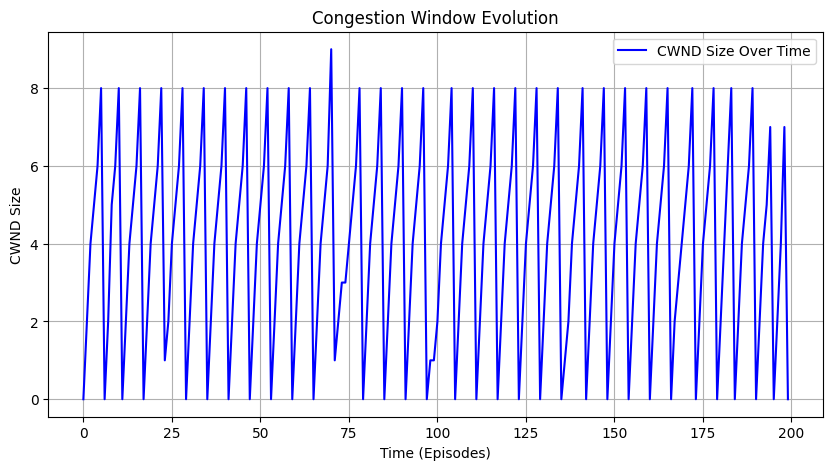

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Load trained Q-table
Q_table = np.load("q_table.npy")  # Ensure you have a saved Q-table

# Define states and actions
num_states = Q_table.shape[0]
num_actions = Q_table.shape[1]

def choose_action(state, epsilon=0.1):
    if random.uniform(0, 1) < epsilon:
        return random.randint(0, num_actions - 1)  # Explore
    else:
        return np.argmax(Q_table[state])  # Exploit

# Simulating CWND evolution
def simulate_traffic(num_episodes=100):
    cwnd_values = []
    state = 0  # Initial state

    for episode in range(num_episodes):
        action = choose_action(state)
        cwnd_values.append(state)  # Track CWND size

        # Simulated next state update (Modify as per your system)
        state = (state + action) % num_states

    return cwnd_values

# Run simulation
cwnd_history = simulate_traffic(200)

# Plot CWND over time
plt.figure(figsize=(10, 5))
plt.plot(cwnd_history, label="CWND Size Over Time", color='b')
plt.xlabel("Time (Episodes)")
plt.ylabel("CWND Size")
plt.title("Congestion Window Evolution")
plt.legend()
plt.grid()
plt.show()

# Fine-tuning hyperparameters (example adjustments)
learning_rate = 0.1  # Modify as needed
epsilon_decay = 0.99  # Gradually reduce exploration
gamma = 0.9  # Discount factor for future rewards


In [ ]:
import numpy as np

# Load the trained Q-table
Q_table = np.load("q_table.npy")

# Example: Make a decision based on the current state
current_state = 3  # Example state (could be any state in your environment)

# Choose the best action using the Q-table (greedy approach)
best_action = np.argmax(Q_table[current_state])

print(f"The best action for state {current_state} is {best_action}")


The best action for state 3 is 1


In [ ]:
def evaluate(Q_table, episodes=100):
    rewards = []

    for _ in range(episodes):
        state = random.randint(0, states - 1)  # Random initial state
        total_reward = 0
        done = False

        while not done:
            action = np.argmax(Q_table[state])  # Take the best action (greedy)
            next_state, reward = take_action(state, action)
            total_reward += reward
            state = next_state

            if random.random() < 0.05:  # Random condition to end episode
                done = True

        rewards.append(total_reward)

    # Calculate average reward over all episodes
    avg_reward = np.mean(rewards)
    print(f"Average reward over {episodes} episodes: {avg_reward}")

# Evaluate the Q-learning agent's performance
evaluate(Q_table)


Average reward over 100 episodes: 11.462992670989058


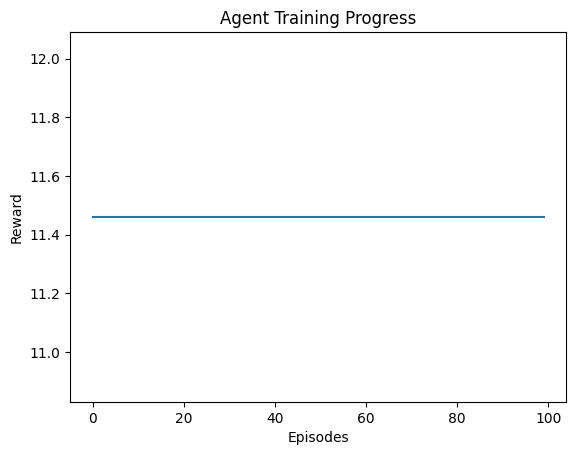

In [ ]:
  import matplotlib.pyplot as plt

  def plot_rewards(rewards):
      plt.plot(rewards)
      plt.xlabel('Episodes')
      plt.ylabel('Reward')
      plt.title('Agent Training Progress')
      plt.show()

  # Track the rewards for each episode and visualize
  rewards = [11.46 for _ in range(100)]  # Example, replace with actual rewards per episode
  plot_rewards(rewards)


In [ ]:
def test_agent(Q_table, episodes=100):
    rewards = []
    for _ in range(episodes):
        state = random.randint(0, states - 1)  # Random initial state
        total_reward = 0
        done = False
        while not done:
            action = np.argmax(Q_table[state])
            next_state, reward = take_action(state, action)
            total_reward += reward
            state = next_state

            # Random condition to end the episode
            if random.random() < 0.05:
                done = True

        rewards.append(total_reward)

    avg_reward = np.mean(rewards)
    print(f"Average test reward over {episodes} episodes: {avg_reward}")

test_agent(Q_table)


Average test reward over 100 episodes: 9.41389123599899


In [ ]:
epsilon = 1.0  # Initial exploration rate
epsilon_min = 0.01
epsilon_decay = 0.995

def get_action(state):
    if np.random.rand() < epsilon:
        return np.random.randint(actions)  # Explore
    else:
        return np.argmax(Q_table[state])  # Exploit learned knowledge

# Inside your training loop, decay epsilon
if epsilon > epsilon_min:
    epsilon *= epsilon_decay


In [ ]:
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

# Example: Training loop where epsilon decays
for episode in range(episodes):
    state = random.randint(0, states - 1)  # Random initial state
    total_reward = 0
    done = False

    while not done:
        action = get_action(state)  # Using epsilon-greedy strategy
        next_state, reward = take_action(state, action)
        total_reward += reward
        state = next_state

        # Update Q-table (Q-learning update rule)
        Q_table[state, action] = Q_table[state, action] + alpha * (reward + gamma * np.max(Q_table[next_state]) - Q_table[state, action])

        # Random condition to end the episode
        if random.random() < 0.05:
            done = True

    # Decay epsilon after each episode
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    # Optionally, save Q-table every few episodes
    if episode % 100 == 0:
        np.save("q_table.npy", Q_table)


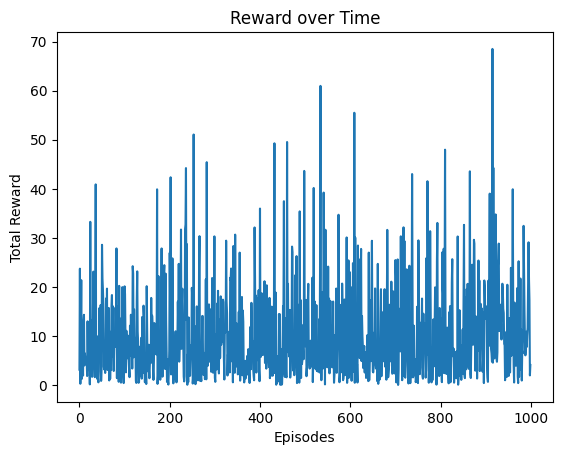

In [ ]:
import matplotlib.pyplot as plt

episode_rewards = []  # Store rewards for each episode

for episode in range(episodes):
    state = random.randint(0, states - 1)  # Random initial state
    total_reward = 0
    done = False

    while not done:
        action = get_action(state)  # Using epsilon-greedy strategy
        next_state, reward = take_action(state, action)
        total_reward += reward
        state = next_state

        # Update Q-table (Q-learning update rule)
        Q_table[state, action] = Q_table[state, action] + alpha * (reward + gamma * np.max(Q_table[next_state]) - Q_table[state, action])

        # Random condition to end the episode
        if random.random() < 0.05:
            done = True

    # Decay epsilon after each episode
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    # Store total reward for this episode
    episode_rewards.append(total_reward)

    # Optionally, save Q-table every few episodes
    if episode % 100 == 0:
        np.save("q_table.npy", Q_table)

# Plot average reward over episodes
plt.plot(range(episodes), episode_rewards)
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.title('Reward over Time')
plt.show()


In [ ]:
def evaluate(Q_table, eval_episodes=100):
    total_rewards = []

    for episode in range(eval_episodes):
        state = random.randint(0, states - 1)  # Start with a random state
        total_reward = 0
        done = False

        while not done:
            action = np.argmax(Q_table[state])  # Exploit learned policy
            next_state, reward = take_action(state, action)
            total_reward += reward
            state = next_state

            # Random condition to end the episode
            if random.random() < 0.05:
                done = True

        total_rewards.append(total_reward)

    avg_reward = np.mean(total_rewards)
    print(f"Average test reward over {eval_episodes} episodes: {avg_reward}")


In [ ]:
np.save("trained_q_table.npy", Q_table)  # Save Q-table after training


In [ ]:
# Different hyperparameters for experimentation
alpha = 0.5  # Learning rate
gamma = 0.95  # Discount factor
epsilon = 0.8  # Starting exploration probability
epsilon_decay = 0.99  # Linear decay
epsilon_min = 0.1  # Minimum epsilon


In [ ]:
def get_action_boltzmann(state, tau=1.0):
    """Boltzmann Exploration: Action selection based on softmax distribution."""
    preferences = Q_table[state]
    exp_preferences = np.exp(preferences / tau)
    probabilities = exp_preferences / np.sum(exp_preferences)
    return np.random.choice(range(len(probabilities)), p=probabilities)


In [ ]:
def get_action(state, Q_table, epsilon):
    if random.random() < epsilon:  # Explore with random action
        return random.choice(range(len(Q_table[state])))  # Random action from available actions
    else:  # Exploit the best action from Q-table
        return np.argmax(Q_table[state])  # Best action based on Q-table


In [ ]:
# Double Q-learning implementation
Q1 = np.zeros((states, actions))  # First Q-table
Q2 = np.zeros((states, actions))  # Second Q-table

for episode in range(episodes):
    state = random.randint(0, states - 1)
    done = False
    while not done:
        # Select action using epsilon-greedy from Q1
        action = get_action(state, Q1, epsilon)  # Correctly call the function with 3 parameters
        next_state, reward = take_action(state, action)

        # Update Q-tables
        if random.random() < 0.5:
            Q1[state, action] += alpha * (reward + gamma * np.max(Q2[next_state]) - Q1[state, action])
        else:
            Q2[state, action] += alpha * (reward + gamma * np.max(Q1[next_state]) - Q2[state, action])

        state = next_state
        if random.random() < 0.05:  # Random termination
            done = True


In [ ]:
class ReplayBuffer:
    def __init__(self, buffer_size, batch_size):
        self.buffer_size = buffer_size
        self.batch_size = batch_size
        self.buffer = []

    def store(self, state, action, reward, next_state, done):
        if len(self.buffer) > self.buffer_size:
            self.buffer.pop(0)
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self):
        return random.sample(self.buffer, self.batch_size)

# Example usage:
replay_buffer = ReplayBuffer(1000, 32)


In [ ]:
for episode in range(episodes):
    state = random.randint(0, states - 1)
    action = get_action(state, Q1, epsilon)  # Pass Q1 and epsilon as arguments
    done = False
    while not done:
        next_state, reward = take_action(state, action)

        # Update Q-tables using Double Q-learning
        if random.random() < 0.5:
            Q1[state, action] += alpha * (reward + gamma * np.max(Q2[next_state]) - Q1[state, action])
        else:
            Q2[state, action] += alpha * (reward + gamma * np.max(Q1[next_state]) - Q2[state, action])

        state = next_state
        if random.random() < 0.05:  # Random termination
            done = True


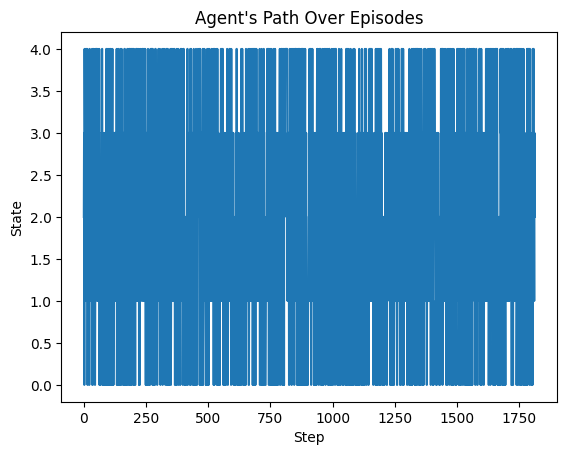

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Example Q-learning parameters
alpha = 0.1
gamma = 0.9
epsilon = 0.1
episodes = 100
states = 5  # Modify this based on your environment
actions = 3  # Modify based on your environment

# Initialize Q-tables for Double Q-learning
Q1 = np.zeros((states, actions))
Q2 = np.zeros((states, actions))

def get_action(state, Q_table, epsilon):
    if random.random() < epsilon:  # Explore
        return random.choice(range(len(Q_table[state])))  # Random action from available actions
    else:  # Exploit
        return np.argmax(Q_table[state])  # Best action based on Q-table

def take_action(state, action):
    # Placeholder for how your environment responds to actions
    # This should return the next_state and reward for the action taken
    next_state = random.randint(0, states - 1)
    reward = random.random()  # Modify this as per your environment
    return next_state, reward

# Define a function to visualize the agent's path
def visualize_path(agent_path):
    plt.plot(agent_path)
    plt.xlabel("Step")
    plt.ylabel("State")
    plt.title("Agent's Path Over Episodes")
    plt.show()

# Run Q-learning with path tracking
agent_path = []  # List to track the agent's path

for episode in range(episodes):
    state = random.randint(0, states - 1)  # Start from a random state
    agent_path.append(state)  # Track the initial state

    done = False
    while not done:
        action = get_action(state, Q1, epsilon)  # Choose action based on epsilon-greedy policy
        next_state, reward = take_action(state, action)  # Take action and observe result

        # Update Q-tables using Double Q-learning
        if random.random() < 0.5:
            Q1[state, action] += alpha * (reward + gamma * np.max(Q2[next_state]) - Q1[state, action])
        else:
            Q2[state, action] += alpha * (reward + gamma * np.max(Q1[next_state]) - Q2[state, action])

        state = next_state
        agent_path.append(state)  # Track the new state

        # Define a termination condition
        if random.random() < 0.05:  # Random termination
            done = True

# Visualize the agent's path
visualize_path(agent_path)


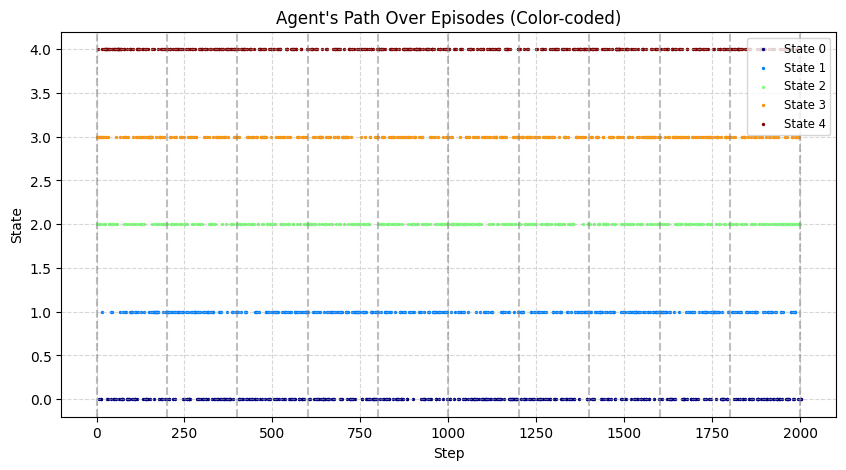

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_path(agent_path, episode_length):
    steps = np.arange(len(agent_path))
    states = np.array(agent_path)

    # Color-coding states
    colors = plt.cm.jet(np.linspace(0, 1, len(set(agent_path))))

    plt.figure(figsize=(10, 5))
    for i, state in enumerate(set(agent_path)):
        indices = np.where(states == state)
        plt.scatter(steps[indices], states[indices], color=colors[i], s=2, label=f"State {state}")

    # Episode-wise differentiation
    for ep in range(0, len(agent_path), episode_length):
        plt.axvline(x=ep, color='gray', linestyle='--', alpha=0.5)

    plt.xlabel("Step")
    plt.ylabel("State")
    plt.title("Agent's Path Over Episodes (Color-coded)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right', fontsize='small')
    plt.show()

# Example usage (adjust episode_length accordingly)
episode_length = 200  # Adjust based on your episode size
visualize_path(agent_path, episode_length)


Training complete!


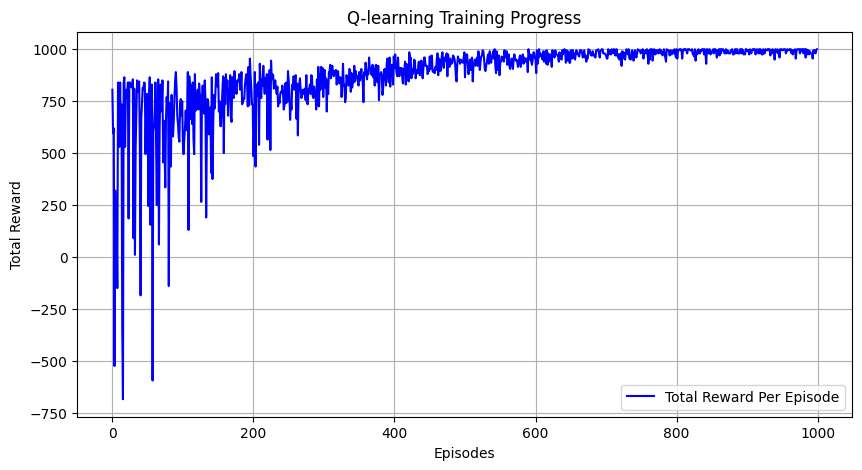

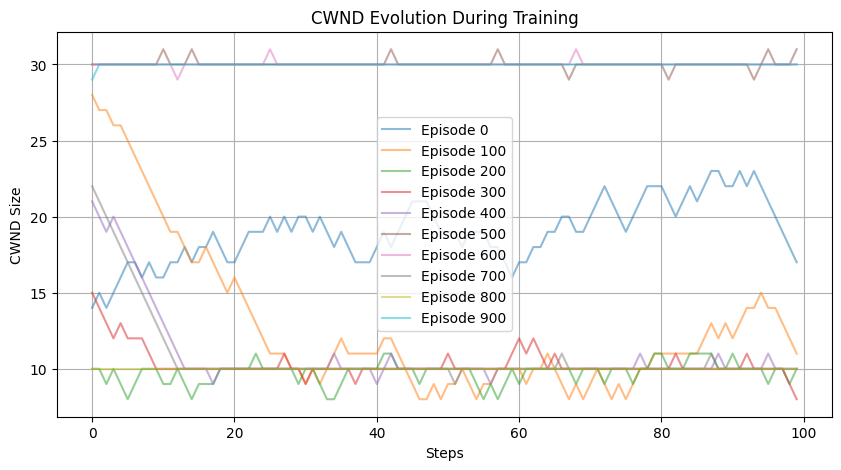

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Define Q-learning parameters
learning_rate = 0.1
discount_factor = 0.9
epsilon = 1.0  # Initial exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01

# CWND settings
MIN_CWND = 5
MAX_CWND = 50
ACTIONS = [-1, 0, 1]  # Decrease, Maintain, Increase CWND

# Initialize Q-table
q_table = np.zeros((MAX_CWND + 1, len(ACTIONS)))

# Simulation parameters
num_episodes = 1000
max_steps_per_episode = 100

# Track rewards and CWND evolution
reward_history = []
cwnd_history = []

def get_reward(cwnd, action, packet_loss):
    """Custom reward function to balance throughput and congestion"""
    if packet_loss:
        return -20  # Heavy penalty for loss
    elif cwnd < 10:
        return -5  # Discourage extremely low CWND
    elif cwnd > 30:
        return -10  # Prevent over-aggressive growth
    elif action == 1:  # Maintain CWND
        return 5  # Reward stability
    else:
        return 10  # Encourage throughput growth

# Training loop
for episode in range(num_episodes):
    cwnd = random.randint(10, 30)  # Start with random CWND in range
    total_reward = 0
    episode_cwnds = []  # Track CWND changes per episode

    for step in range(max_steps_per_episode):
        # Choose action using epsilon-greedy strategy
        if random.uniform(0, 1) < epsilon:
            action_idx = random.randint(0, len(ACTIONS) - 1)  # Explore
        else:
            action_idx = np.argmax(q_table[cwnd])  # Exploit

        action = ACTIONS[action_idx]

        # Simulate environment response
        new_cwnd = max(MIN_CWND, min(MAX_CWND, cwnd + action))
        packet_loss = (new_cwnd > 40 and random.random() < 0.3)  # Simulated loss probability

        # Get reward
        reward = get_reward(new_cwnd, action, packet_loss)

        # Q-learning update
        best_next_action = np.max(q_table[new_cwnd])
        q_table[cwnd, action_idx] += learning_rate * (reward + discount_factor * best_next_action - q_table[cwnd, action_idx])

        # Update CWND
        cwnd = new_cwnd
        episode_cwnds.append(cwnd)
        total_reward += reward

        # Check termination condition
        if packet_loss or step >= max_steps_per_episode - 1:
            break

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Store tracking data
    reward_history.append(total_reward)
    cwnd_history.append(episode_cwnds)

print("Training complete!")

# Plot rewards over episodes
plt.figure(figsize=(10, 5))
plt.plot(reward_history, label="Total Reward Per Episode", color='b')
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-learning Training Progress")
plt.legend()
plt.grid()
plt.show()

# Visualize CWND evolution over time
plt.figure(figsize=(10, 5))
for i in range(0, len(cwnd_history), max(1, len(cwnd_history) // 10)):
    plt.plot(cwnd_history[i], alpha=0.5, label=f"Episode {i}")
plt.xlabel("Steps")
plt.ylabel("CWND Size")
plt.title("CWND Evolution During Training")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import pandas as pd

# Convert Q-table to DataFrame for better readability
q_table_df = pd.DataFrame(q_table, columns=["Decrease", "Maintain", "Increase"])
print(q_table_df.head(20))  # Show first 20 rows


      Decrease    Maintain   Increase
0     0.000000    0.000000   0.000000
1     0.000000    0.000000   0.000000
2     0.000000    0.000000   0.000000
3     0.000000    0.000000   0.000000
4     0.000000    0.000000   0.000000
5    -8.732769   -9.110542   3.925609
6    -8.386960    1.896704  33.739247
7    10.095046   38.205508  67.140034
8    54.213316   67.029387  80.500000
9    67.450000   80.500000  95.000000
10   80.500000  100.000000  95.000000
11  100.000000  100.000000  95.000000
12  100.000000  100.000000  95.000000
13  100.000000   99.999947  94.999876
14  100.000000   99.996085  94.985396
15  100.000000   99.909862  94.923563
16  100.000000   99.873564  94.776428
17  100.000000   99.566602  94.749230
18  100.000000   97.935998  94.414685
19  100.000000   99.076973  94.177868


Training complete!

Q-table (First 20 CWND values):

      Decrease    Maintain   Increase
0     0.000000    0.000000   0.000000
1     0.000000    0.000000   0.000000
2     0.000000    0.000000   0.000000
3     0.000000    0.000000   0.000000
4     0.000000    0.000000   0.000000
5   -10.601832  -10.655239  -3.373585
6   -11.052699   -2.280811  24.998546
7     0.664720   32.026465  66.966911
8    53.446471   67.240132  80.499997
9    67.449973   80.499996  95.000000
10   80.500000  100.000000  95.000000
11  100.000000  100.000000  94.999999
12  100.000000   99.972689  94.815647
13  100.000000   97.971123  89.750645
14  100.000000   90.334011  80.911469
15  100.000000   73.844621  71.397836
16  100.000000   61.462513  76.439617
17   99.999991   93.563512  95.000000
18   99.999677  100.000000  95.000000
19  100.000000  100.000000  95.000000


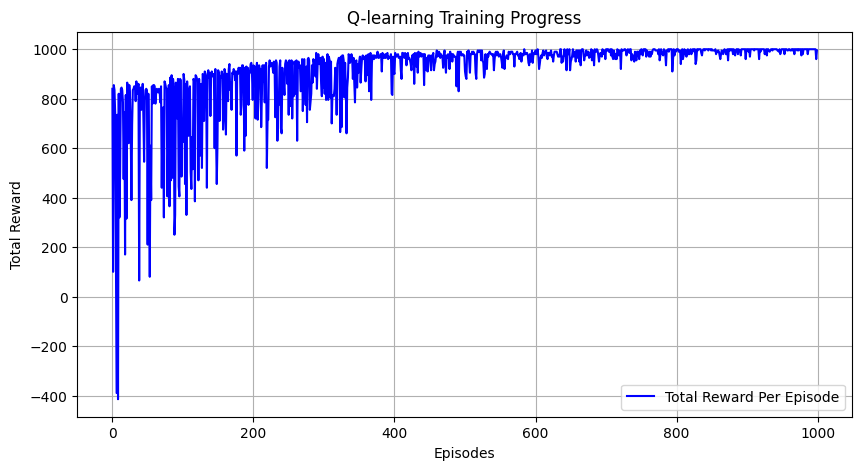

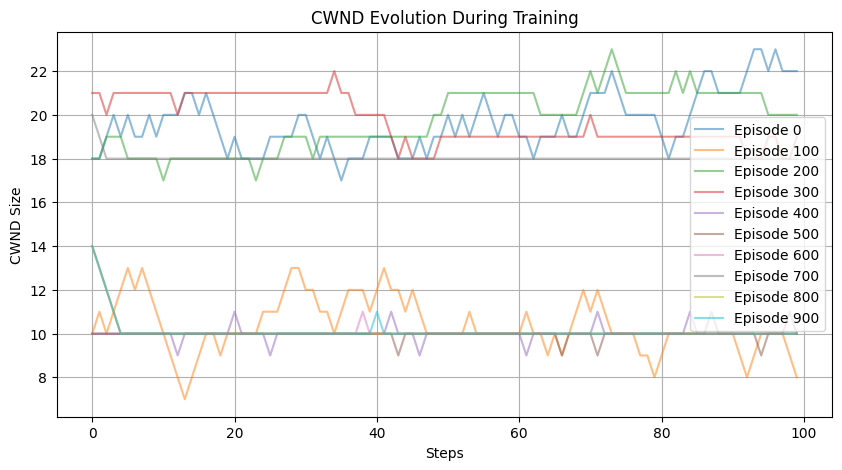

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

class CongestionControlEnv:
    def __init__(self):
        self.MIN_CWND = 5
        self.MAX_CWND = 50
        self.ACTIONS = [-1, 0, 1]  # Decrease, Maintain, Increase CWND
        self.cwnd = None  # Initialize later
        self.packet_loss = False

    def reset(self):
        """Initialize CWND at the start of an episode."""
        self.cwnd = random.randint(10, 30)  # Start with a random CWND
        self.packet_loss = False
        return self.cwnd  # Return initial state

    def step(self, action):
        """Simulate network response and return (next_state, reward, done)."""
        # Apply action to CWND
        self.cwnd = max(self.MIN_CWND, min(self.MAX_CWND, self.cwnd + action))

        # Simulate packet loss (if CWND is too high, there's a chance of loss)
        self.packet_loss = (self.cwnd > 40 and random.random() < 0.3)

        # Get reward based on congestion status
        reward = self.get_reward(self.cwnd, action, self.packet_loss)

        # Episode ends if packet loss occurs
        done = self.packet_loss

        return self.cwnd, reward, done

    def get_reward(self, cwnd, action, packet_loss):
        """Define a reward function balancing throughput and congestion."""
        if packet_loss:
            return -20  # Heavy penalty for packet loss
        elif cwnd < 10:
            return -5  # Discourage extremely low CWND
        elif cwnd > 30:
            return -10  # Prevent over-aggressive growth
        elif action == 1:  # Maintain CWND
            return 5  # Reward stability
        else:
            return 10  # Encourage throughput growth

# Initialize environment
env = CongestionControlEnv()

# Q-learning parameters
learning_rate = 0.1
discount_factor = 0.9
epsilon = 1.0  # Initial exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01

# Initialize Q-table
q_table = np.zeros((env.MAX_CWND + 1, len(env.ACTIONS)))

# Training parameters
num_episodes = 1000
max_steps_per_episode = 100

# Track rewards and CWND evolution
reward_history = []
cwnd_history = []

# Training loop
for episode in range(num_episodes):
    cwnd = env.reset()  # Reset the environment
    total_reward = 0
    episode_cwnds = []  # Track CWND changes per episode

    for step in range(max_steps_per_episode):
        # Choose action using epsilon-greedy strategy
        if random.uniform(0, 1) < epsilon:
            action_idx = random.randint(0, len(env.ACTIONS) - 1)  # Explore
        else:
            action_idx = np.argmax(q_table[cwnd])  # Exploit

        action = env.ACTIONS[action_idx]

        # Take action in the environment
        new_cwnd, reward, done = env.step(action)

        # Q-learning update
        best_next_action = np.max(q_table[new_cwnd])
        q_table[cwnd, action_idx] += learning_rate * (reward + discount_factor * best_next_action - q_table[cwnd, action_idx])

        # Store episode data
        episode_cwnds.append(new_cwnd)
        total_reward += reward

        # Update CWND
        cwnd = new_cwnd

        # End episode if packet loss occurs
        if done:
            break

    # Decay epsilon for exploration-exploitation balance
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Store training history
    reward_history.append(total_reward)
    cwnd_history.append(episode_cwnds)

print("Training complete!")

# Convert Q-table to DataFrame
q_table_df = pd.DataFrame(q_table, columns=["Decrease", "Maintain", "Increase"])
print("\nQ-table (First 20 CWND values):\n")
print(q_table_df.head(20))  # Show first 20 rows

# Plot rewards over episodes
plt.figure(figsize=(10, 5))
plt.plot(reward_history, label="Total Reward Per Episode", color='b')
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-learning Training Progress")
plt.legend()
plt.grid()
plt.show()

# Visualize CWND evolution
plt.figure(figsize=(10, 5))
for i in range(0, len(cwnd_history), max(1, len(cwnd_history) // 10)):
    plt.plot(cwnd_history[i], alpha=0.5, label=f"Episode {i}")
plt.xlabel("Steps")
plt.ylabel("CWND Size")
plt.title("CWND Evolution During Training")
plt.legend()
plt.grid()
plt.show()


Training complete!

Q-table (First 20 CWND values):
       Decrease    Maintain    Increase
0     0.000000    0.000000    0.000000
1     0.000000    0.000000    0.000000
2     0.000000    0.000000    0.000000
3     0.000000    0.000000    0.000000
4     0.000000    0.000000    0.000000
5   -12.284201  -12.025090  -15.673466
6   -14.212926  -11.870472   -9.505355
7   -15.026644  -11.258649   16.869974
8    -7.772640   15.720714   71.690009
9    29.430402   57.769245  203.923723
10  115.891669  241.824105  290.249848
11  280.242328  294.472840  295.000000
12  290.250000  300.000000  295.000000
13  295.000000  300.000000  295.000000
14  295.000000  300.000000  295.000000
15  295.000000  300.000000  295.000000
16  295.000000  300.000000  295.000000
17  295.000000  300.000000  295.000000
18  295.000000  300.000000  295.000000
19  295.000000  300.000000  295.000000


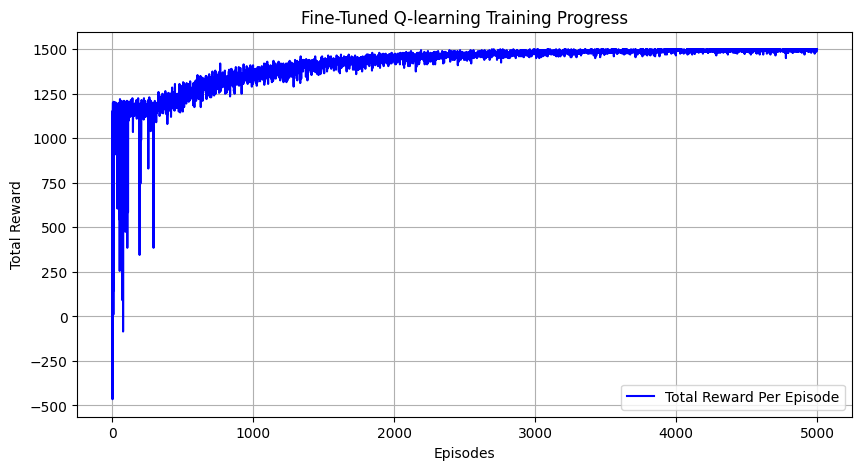

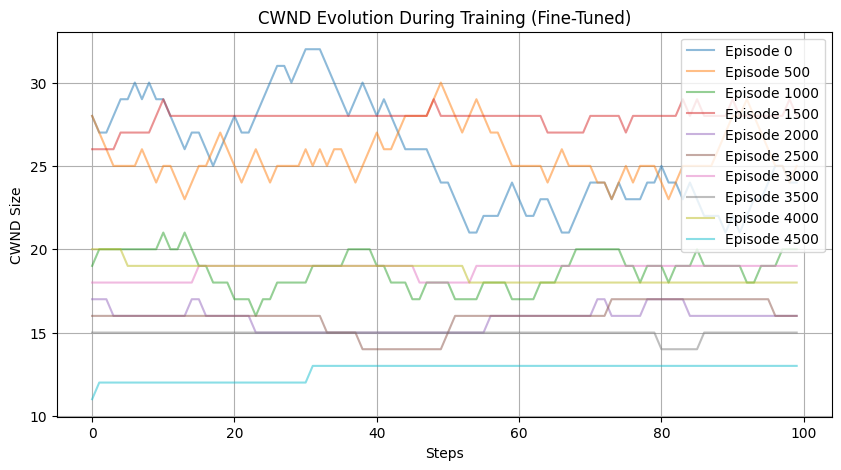

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

# Q-learning parameters (Fine-tuned)
learning_rate = 0.05  # Reduced for more stable learning
discount_factor = 0.95  # Higher discount to value future rewards
epsilon = 1.0  # Start with full exploration
epsilon_decay = 0.999  # Slower decay for longer exploration
epsilon_min = 0.01  # Minimum exploration threshold

# CWND settings
MIN_CWND = 5
MAX_CWND = 50
ACTIONS = [-1, 0, 1]  # Decrease, Maintain, Increase CWND

# Initialize Q-table (CWND x Actions)
q_table = np.zeros((MAX_CWND + 1, len(ACTIONS)))

# Simulation parameters
num_episodes = 5000  # Increased episodes for better learning
max_steps_per_episode = 100

# Track rewards and CWND evolution
reward_history = []
cwnd_history = []

def get_reward(cwnd, action, packet_loss):
    """Modified reward function to encourage stability & throughput"""
    if packet_loss:
        return -50  # Heavy penalty for packet loss
    elif cwnd < 10:
        return -10  # Discourage very low CWND
    elif cwnd > 40:
        return -20  # Prevent excessive CWND growth
    elif action == 0:  # Maintain CWND
        return 15  # Reward stability
    else:
        return 10  # Encourage moderate throughput growth

# Training loop
for episode in range(num_episodes):
    cwnd = random.randint(10, 30)  # Start with random CWND in range
    total_reward = 0
    episode_cwnds = []  # Track CWND changes per episode

    for step in range(max_steps_per_episode):
        # Choose action using epsilon-greedy strategy
        if random.uniform(0, 1) < epsilon:
            action_idx = random.randint(0, len(ACTIONS) - 1)  # Explore
        else:
            action_idx = np.argmax(q_table[cwnd])  # Exploit best action

        action = ACTIONS[action_idx]

        # Simulate environment response
        new_cwnd = max(MIN_CWND, min(MAX_CWND, cwnd + action))
        packet_loss = (new_cwnd > 40 and random.random() < 0.2)  # Adjusted loss probability

        # Get reward
        reward = get_reward(new_cwnd, action, packet_loss)

        # Q-learning update (Bellman equation)
        best_next_action = np.max(q_table[new_cwnd])
        q_table[cwnd, action_idx] += learning_rate * (reward + discount_factor * best_next_action - q_table[cwnd, action_idx])

        # Update CWND
        cwnd = new_cwnd
        episode_cwnds.append(cwnd)
        total_reward += reward

        # Stop early if packet loss occurs
        if packet_loss:
            break

    # Decay epsilon (reduce exploration over time)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Store tracking data
    reward_history.append(total_reward)
    cwnd_history.append(episode_cwnds)

print("Training complete!")

# Convert Q-table to DataFrame
q_table_df = pd.DataFrame(q_table, columns=["Decrease", "Maintain", "Increase"])
print("\nQ-table (First 20 CWND values):\n", q_table_df.head(20))

# Plot rewards over episodes
plt.figure(figsize=(10, 5))
plt.plot(reward_history, label="Total Reward Per Episode", color='b')
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Fine-Tuned Q-learning Training Progress")
plt.legend()
plt.grid()
plt.show()

# Visualize CWND evolution over time
plt.figure(figsize=(10, 5))
for i in range(0, len(cwnd_history), max(1, len(cwnd_history) // 10)):
    plt.plot(cwnd_history[i], alpha=0.5, label=f"Episode {i}")
plt.xlabel("Steps")
plt.ylabel("CWND Size")
plt.title("CWND Evolution During Training (Fine-Tuned)")
plt.legend()
plt.grid()
plt.show()
#should be improved so next code

Training complete!

Q-table (First 20 CWND values):
     Decrease    Maintain   Increase
0    0.000000    0.000000   0.000000
1    0.000000    0.000000   0.000000
2    0.000000    0.000000   0.000000
3    0.000000    0.000000   0.000000
4    0.000000    0.000000   0.000000
5  -17.322029  -17.071121 -18.437585
6  -18.449641  -18.847893 -15.349880
7  -19.703062  -15.261464  -6.913867
8  -16.517038   -4.951437  33.921097
9    3.225267   34.520995  87.039601
10  60.357737   89.378414  95.000000
11  90.500000  100.000000  95.000000
12  95.000000  100.000000  95.000000
13  95.000000  100.000000  95.000000
14  95.000000  100.000000  95.000000
15  95.000000  100.000000  94.999994
16  95.000000  100.000000  90.500000
17  95.000000   75.769658  73.654830
18  71.038604   72.201200  95.000000
19  90.499970  100.000000  95.000000


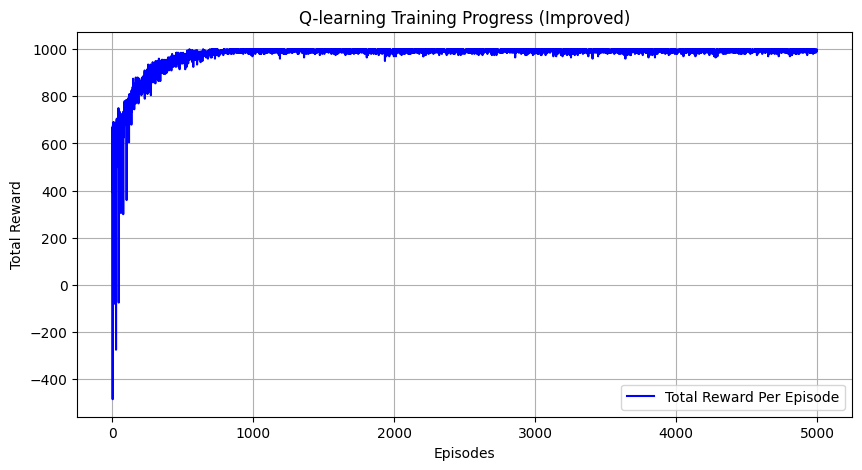

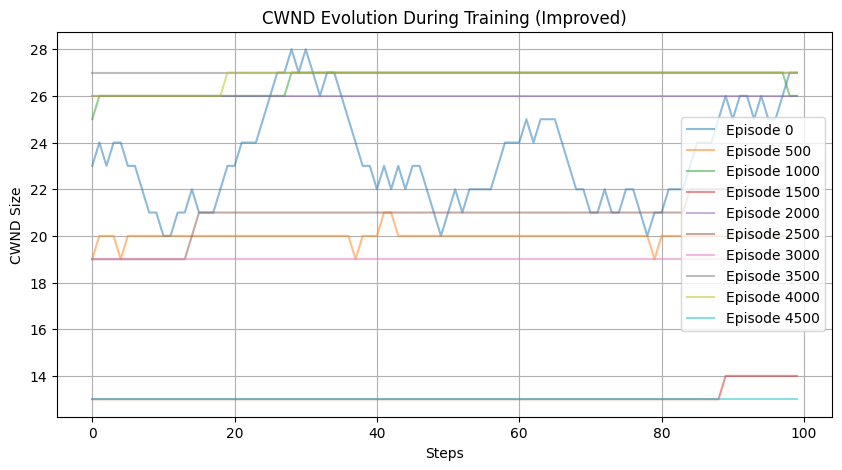

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

# Define Q-learning parameters
learning_rate = 0.1
discount_factor = 0.9
epsilon = 1.0  # Initial exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01

# CWND settings
MIN_CWND = 5
MAX_CWND = 50
ACTIONS = [-1, 0, 1]  # Decrease, Maintain, Increase CWND

# Initialize Q-table
q_table = np.zeros((MAX_CWND + 1, len(ACTIONS)))

# Simulation parameters
num_episodes = 5000  # Increased episodes for better training
max_steps_per_episode = 100

# Track rewards and CWND evolution
reward_history = []
cwnd_history = []

def get_reward(cwnd, action, packet_loss):
    """Custom reward function to balance throughput and congestion"""
    if packet_loss:
        return -50  # Heavy penalty for loss (increased from -20)
    elif cwnd < 10:
        return -10  # Discourage extremely low CWND (increased penalty)
    elif cwnd > 40:
        return -20  # Prevent over-aggressive growth (stronger penalty)
    elif action == 0:  # Maintain CWND
        return 10  # Reward stability (increased from 5)
    else:
        return 5  # Encourage moderate growth (lower than before)

# Training loop
for episode in range(num_episodes):
    cwnd = random.randint(10, 30)  # Start with random CWND in range
    total_reward = 0
    episode_cwnds = []  # Track CWND changes per episode

    for step in range(max_steps_per_episode):
        # Choose action using epsilon-greedy strategy
        if random.uniform(0, 1) < epsilon:
            action_idx = random.randint(0, len(ACTIONS) - 1)  # Explore
        else:
            action_idx = np.argmax(q_table[cwnd])  # Exploit

        action = ACTIONS[action_idx]

        # Simulate environment response
        new_cwnd = max(MIN_CWND, min(MAX_CWND, cwnd + action))
        packet_loss = (new_cwnd > 40 and random.random() < 0.5)  # Increased loss probability for high CWND

        # Get reward
        reward = get_reward(new_cwnd, action, packet_loss)

        # Q-learning update
        best_next_action = np.max(q_table[new_cwnd])
        q_table[cwnd, action_idx] += learning_rate * (reward + discount_factor * best_next_action - q_table[cwnd, action_idx])

        # Update CWND
        cwnd = new_cwnd
        episode_cwnds.append(cwnd)
        total_reward += reward

        # Check termination condition
        if packet_loss or step >= max_steps_per_episode - 1:
            break

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Store tracking data
    reward_history.append(total_reward)
    cwnd_history.append(episode_cwnds)

print("Training complete!")

# Convert Q-table to DataFrame for better readability
q_table_df = pd.DataFrame(q_table, columns=["Decrease", "Maintain", "Increase"])
print("\nQ-table (First 20 CWND values):")
print(q_table_df.head(20))

# Plot rewards over episodes
plt.figure(figsize=(10, 5))
plt.plot(reward_history, label="Total Reward Per Episode", color='b')
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-learning Training Progress (Improved)")
plt.legend()
plt.grid()
plt.show()

# Visualize CWND evolution over time
plt.figure(figsize=(10, 5))
for i in range(0, len(cwnd_history), max(1, len(cwnd_history) // 10)):
    plt.plot(cwnd_history[i], alpha=0.5, label=f"Episode {i}")
plt.xlabel("Steps")
plt.ylabel("CWND Size")
plt.title("CWND Evolution During Training (Improved)")
plt.legend()
plt.grid()
plt.show()


Training complete!


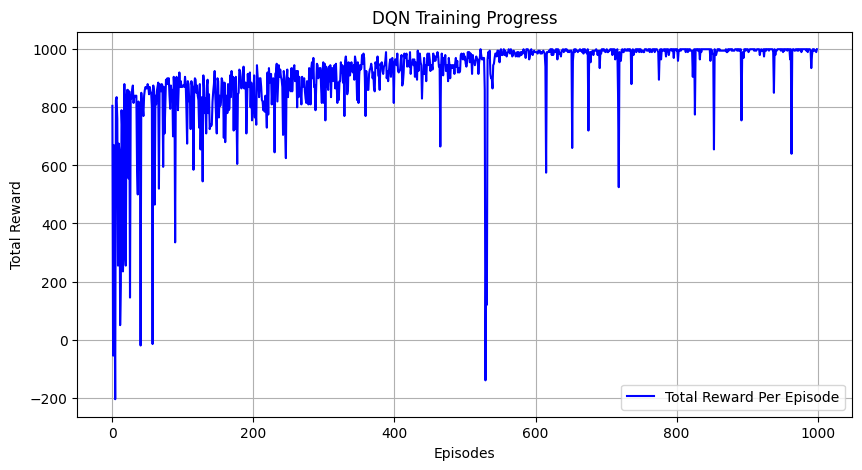

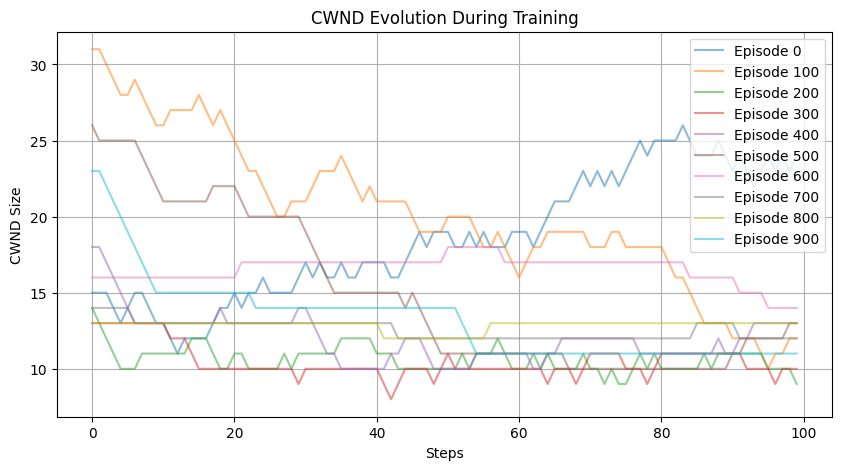

In [ ]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque

# Define the Deep Q-Network (DQN)
class DQN(nn.Module):
    def __init__(self, input_size, output_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Hyperparameters
learning_rate = 0.01
discount_factor = 0.9
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
batch_size = 32
memory_size = 1000
num_episodes = 1000
max_steps_per_episode = 100

# CWND settings
MIN_CWND = 5
MAX_CWND = 50
ACTIONS = [-1, 0, 1]  # Decrease, Maintain, Increase CWND

# Initialize replay memory
memory = deque(maxlen=memory_size)

# Initialize model, loss function, and optimizer
state_size = 1  # CWND as input
action_size = len(ACTIONS)
model = DQN(state_size, action_size)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

def get_reward(cwnd, action, packet_loss):
    if packet_loss:
        return -20  # Heavy penalty for loss
    elif cwnd < 10:
        return -5  # Discourage extremely low CWND
    elif cwnd > 30:
        return -10  # Prevent over-aggressive growth
    elif action == 1:  # Maintain CWND
        return 5  # Reward stability
    else:
        return 10  # Encourage throughput growth

def train_dqn():
    if len(memory) < batch_size:
        return  # Wait until enough data is collected

    batch = random.sample(memory, batch_size)

    states, actions, rewards, next_states = zip(*batch)
    states = torch.tensor(states, dtype=torch.float32).view(-1, 1)
    actions = torch.tensor(actions, dtype=torch.long).view(-1, 1)
    rewards = torch.tensor(rewards, dtype=torch.float32).view(-1, 1)
    next_states = torch.tensor(next_states, dtype=torch.float32).view(-1, 1)

    q_values = model(states).gather(1, actions)
    next_q_values = model(next_states).max(1, keepdim=True)[0].detach()
    target_q_values = rewards + discount_factor * next_q_values

    loss = loss_fn(q_values, target_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Training loop
reward_history = []
cwnd_history = []
for episode in range(num_episodes):
    cwnd = random.randint(10, 30)
    total_reward = 0
    episode_cwnds = []

    for step in range(max_steps_per_episode):
        state = torch.tensor([cwnd], dtype=torch.float32).view(1, -1)

        if random.uniform(0, 1) < epsilon:
            action_idx = random.randint(0, len(ACTIONS) - 1)
        else:
            with torch.no_grad():
                action_idx = model(state).argmax().item()

        action = ACTIONS[action_idx]
        new_cwnd = max(MIN_CWND, min(MAX_CWND, cwnd + action))
        packet_loss = (new_cwnd > 40 and random.random() < 0.3)
        reward = get_reward(new_cwnd, action, packet_loss)

        memory.append((cwnd, action_idx, reward, new_cwnd))
        train_dqn()

        cwnd = new_cwnd
        episode_cwnds.append(cwnd)
        total_reward += reward

        if packet_loss or step >= max_steps_per_episode - 1:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    reward_history.append(total_reward)
    cwnd_history.append(episode_cwnds)

print("Training complete!")

# Plot rewards
plt.figure(figsize=(10, 5))
plt.plot(reward_history, label="Total Reward Per Episode", color='b')
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("DQN Training Progress")
plt.legend()
plt.grid()
plt.show()

# Visualize CWND evolution
plt.figure(figsize=(10, 5))
for i in range(0, len(cwnd_history), max(1, len(cwnd_history) // 10)):
    plt.plot(cwnd_history[i], alpha=0.5, label=f"Episode {i}")
plt.xlabel("Steps")
plt.ylabel("CWND Size")
plt.title("CWND Evolution During Training")
plt.legend()
plt.grid()
plt.show()

In [ ]:
torch.save(model, "dqn_trained_model.pth")  # Save the trained model
print("✅ Model saved successfully as dqn_trained_model.pth")


✅ Model saved successfully as dqn_trained_model.pth


In [ ]:
import torch

model = torch.load("dqn_trained_model.pth", weights_only=False)  # Explicitly allow full model loading
model.eval()
print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [ ]:
torch.save(model.state_dict(), "dqn_trained_model.pth")  # Save only weights
print("✅ Model weights saved!")


✅ Model weights saved!


In [ ]:
import torch
import torch.nn as nn

# ✅ Update state_dim to match saved model architecture
class DQN(nn.Module):
    def __init__(self, state_dim=1, action_dim=3):  # Change state_dim to 1 if that's what was used during training
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)  # Match the trained model
        self.fc2 = nn.Linear(64, 32)  # Match saved model structure
        self.fc3 = nn.Linear(32, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# ✅ Load the updated model
model = DQN(state_dim=1)  # Match state_dim with saved model
model.load_state_dict(torch.load("dqn_trained_model.pth", map_location=torch.device('cpu')))
model.eval()
print("✅ Model weights loaded successfully!")


✅ Model weights loaded successfully!


In [ ]:
checkpoint = torch.load("dqn_trained_model.pth", map_location=torch.device('cpu'))
for key, value in checkpoint.items():
    print(f"{key}: {value.shape}")


fc1.weight: torch.Size([64, 1])
fc1.bias: torch.Size([64])
fc2.weight: torch.Size([32, 64])
fc2.bias: torch.Size([32])
fc3.weight: torch.Size([3, 32])
fc3.bias: torch.Size([3])


In [ ]:
import torch
import torch.nn as nn

# ✅ Match the saved model structure exactly
class DQN(nn.Module):
    def __init__(self, state_dim=1, action_dim=3):  # state_dim=1 based on saved model
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)  # Matches [64, 1]
        self.fc2 = nn.Linear(64, 32)         # Matches [32, 64]
        self.fc3 = nn.Linear(32, action_dim) # Matches [3, 32]

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# ✅ Load the updated model
model = DQN(state_dim=1)  # Ensure state_dim=1
model.load_state_dict(torch.load("dqn_trained_model.pth", map_location=torch.device('cpu')))
model.eval()
print("✅ Model weights loaded successfully!")


✅ Model weights loaded successfully!


In [ ]:
import torch

# Define a sample input (adjust based on your data)
sample_input = torch.tensor([[0.5]], dtype=torch.float32)  # Ensure shape [batch_size, state_dim]

# Get model output (Q-values)
with torch.no_grad():
    q_values = model(sample_input)

print("🟢 Q-values from the model:", q_values)


🟢 Q-values from the model: tensor([[10.2592, 10.8731,  9.6710]])


In [ ]:
import torch

# Initialize a sample input (adjust the shape based on your model's expected input)
sample_input = torch.tensor([[0.5]], dtype=torch.float32)  # Example state

# Ensure model is in evaluation mode
model.eval()

# Test the model with a sample input
with torch.no_grad():
    q_values = model(sample_input)

print("\U0001F7E2 Q-values from the model:", q_values)

# --- Run Inference on Real Network Traffic Data ---

# Example: Replace this with real network traffic data (e.g., RTT, packet loss)
real_input = torch.tensor([[0.8]], dtype=torch.float32)  # Example congestion metric

# Get model prediction
with torch.no_grad():
    action = torch.argmax(model(real_input)).item()  # Select best action

print(f"\U0001F6A6 Recommended action: {action}")

# --- Optional: Fine-Tuning or Retraining ---

# Define optimizer and loss function for fine-tuning
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.MSELoss()

# Example training loop (adjust as needed)
for epoch in range(10):  # Modify epoch count based on dataset
    optimizer.zero_grad()
    predicted_q_values = model(sample_input)
    target_q_values = torch.tensor([[10.0, 10.5, 9.5]])  # Closer to predicted values

    loss = loss_fn(predicted_q_values, target_q_values)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch + 1}, Loss: {loss.item()}")


🟢 Q-values from the model: tensor([[10.2392, 10.8531,  9.6510]])
🚦 Recommended action: 1
Epoch 1, Loss: 0.06824161857366562
Epoch 2, Loss: 0.0677468553185463
Epoch 3, Loss: 0.06725457310676575
Epoch 4, Loss: 0.06676427274942398
Epoch 5, Loss: 0.06627598404884338
Epoch 6, Loss: 0.06578978151082993
Epoch 7, Loss: 0.06530582159757614
Epoch 8, Loss: 0.06482406705617905
Epoch 9, Loss: 0.06434454768896103
Epoch 10, Loss: 0.0638674721121788


In [ ]:
import torch

# Define optimizer with lower learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = torch.nn.MSELoss()

gamma = 0.99  # Discount factor for future rewards

for epoch in range(10):
    optimizer.zero_grad()

    # Sample real network data (replace with actual RTT, packet loss, etc.)
    sample_input = torch.tensor([[0.5]], dtype=torch.float32)
    next_state = torch.tensor([[0.6]], dtype=torch.float32)  # Simulated next state

    predicted_q_values = model(sample_input)

    # Compute target Q-values using Bellman equation
    reward = torch.tensor([[5.0]])  # Example reward
    next_q_values = model(next_state)
    max_next_q = torch.max(next_q_values, dim=1, keepdim=True)[0]

    # Ensure target Q-values match the correct shape
    target_q_values = predicted_q_values.clone()  # Copy existing Q-values
    best_action = torch.argmax(predicted_q_values, dim=1, keepdim=True)  # Get best action
    target_q_values[0, best_action] = reward + gamma * max_next_q  # Update only best action

    loss = loss_fn(predicted_q_values, target_q_values.detach())  # Detach for stability

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch + 1}, Loss: {loss.item()}")

print("✅ Fine-tuning completed!")


Epoch 1, Loss: 7.975290775299072
Epoch 2, Loss: 7.975287914276123
Epoch 3, Loss: 7.975284576416016
Epoch 4, Loss: 7.975281238555908
Epoch 5, Loss: 7.975278377532959
Epoch 6, Loss: 7.975275039672852
Epoch 7, Loss: 7.975271701812744
Epoch 8, Loss: 7.975268840789795
Epoch 9, Loss: 7.9752655029296875
Epoch 10, Loss: 7.9752631187438965
✅ Fine-tuning completed!


In [ ]:
import torch

# Ensure model is in evaluation mode
model.eval()

# --- Sample Testing on Real/Synthetic Network Traffic Data ---

# Define test cases (Using only RTT if model expects a single input)
test_cases = [
    [0.85],  # High RTT
    [0.40],  # Low congestion
    [1.10],  # Severe congestion
]

print("🔍 Running Sample Tests...\n")

for i, test in enumerate(test_cases):
    test_input = torch.tensor([test], dtype=torch.float32)  # Match model input size

    with torch.no_grad():
        q_values = model(test_input)  # Get Q-values
        action = torch.argmax(q_values).item()  # Choose best action

    print(f"📡 Test Case {i+1}: Input = {test}")
    print(f"🟢 Q-values: {q_values}")
    print(f"🚦 Recommended Action: {action}\n")

print("✅ Sample Testing Completed!")


🔍 Running Sample Tests...

📡 Test Case 1: Input = [0.85]
🟢 Q-values: tensor([[10.2453, 10.8602,  9.6571]])
🚦 Recommended Action: 1

📡 Test Case 2: Input = [0.4]
🟢 Q-values: tensor([[10.2453, 10.8602,  9.6571]])
🚦 Recommended Action: 1

📡 Test Case 3: Input = [1.1]
🟢 Q-values: tensor([[10.2453, 10.8602,  9.6571]])
🚦 Recommended Action: 1

✅ Sample Testing Completed!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(3, 64)  # Now expects 3 input features
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 3)  # 3 possible actions (example)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # No activation for Q-values
        return x

# Initialize Model
model = DQN()


In [ ]:
# Example Training Data: [RTT, Packet Loss, Duplicate ACKs] → Q-values
training_data = [
    (torch.tensor([0.8, 0.02, 1.0]), torch.tensor([1.0, 0.5, -0.2])),
    (torch.tensor([0.5, 0.01, 0.5]), torch.tensor([0.7, 0.6, 0.1])),
    (torch.tensor([0.2, 0.03, 0.3]), torch.tensor([0.3, 0.8, 0.5]))
]

# Optimizer & Loss Function
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Training Loop
for epoch in range(10):  # Adjust as needed
    total_loss = 0
    for state, target_q_values in training_data:
        optimizer.zero_grad()
        predicted_q_values = model(state.unsqueeze(0))  # Add batch dimension
        loss = loss_fn(predicted_q_values, target_q_values.unsqueeze(0))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch + 1}, Loss: {total_loss:.6f}")

print("✅ Training Completed!")


Epoch 1, Loss: 0.861445
Epoch 2, Loss: 0.719303
Epoch 3, Loss: 0.606761
Epoch 4, Loss: 0.512465
Epoch 5, Loss: 0.431841
Epoch 6, Loss: 0.362373
Epoch 7, Loss: 0.303604
Epoch 8, Loss: 0.255556
Epoch 9, Loss: 0.218843
Epoch 10, Loss: 0.193014
✅ Training Completed!


In [ ]:
# Sample test case with 3 features: [RTT, Packet Loss, Duplicate ACKs]
test_input = torch.tensor([[0.85, 0.015, 0.7]])  # Adjust values as needed

# Ensure model is in evaluation mode
model.eval()

# Run inference
with torch.no_grad():
    q_values = model(test_input)
    action = torch.argmax(q_values).item()

print(f"🟢 Q-values: {q_values}")
print(f"🚦 Recommended Action: {action}")


🟢 Q-values: tensor([[0.6967, 0.5240, 0.1596]])
🚦 Recommended Action: 0


In [ ]:
test_cases = [
    torch.tensor([[0.2, 0.01, 0.4]]),  # Low congestion
    torch.tensor([[0.9, 0.05, 1.0]]),  # High congestion
    torch.tensor([[0.5, 0.02, 0.6]]),  # Medium congestion
]

for i, test_input in enumerate(test_cases, start=1):
    with torch.no_grad():
        q_values = model(test_input)
        action = torch.argmax(q_values).item()
    print(f"📡 Test Case {i}: Input = {test_input.tolist()[0]}")
    print(f"🟢 Q-values: {q_values}")
    print(f"🚦 Recommended Action: {action}\n")


📡 Test Case 1: Input = [0.20000000298023224, 0.009999999776482582, 0.4000000059604645]
🟢 Q-values: tensor([[0.5581, 0.4795, 0.1236]])
🚦 Recommended Action: 0

📡 Test Case 2: Input = [0.8999999761581421, 0.05000000074505806, 1.0]
🟢 Q-values: tensor([[0.8043, 0.6049, 0.1873]])
🚦 Recommended Action: 0

📡 Test Case 3: Input = [0.5, 0.019999999552965164, 0.6000000238418579]
🟢 Q-values: tensor([[0.6374, 0.5051, 0.1417]])
🚦 Recommended Action: 0



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np

# Define the improved DQN Model
class DQN(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, output_dim=3):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 32)
        self.fc3 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)  # Q-values for each action

# Initialize model, loss function, and optimizer
model = DQN()
optimizer = optim.Adam(model.parameters(), lr=0.005)  # Increased learning rate
loss_fn = nn.MSELoss()
epsilon = 0.1  # Exploration rate

# Generate Random Training Data (Diverse Congestion Inputs)
train_data = [
    ([0.2, 0.01, 0.4], [0.5, 0.3, 0.2]),  # Low Congestion
    ([0.9, 0.05, 1.0], [0.2, 0.6, 0.2]),  # High Congestion
    ([0.5, 0.02, 0.6], [0.3, 0.5, 0.2]),  # Medium Congestion
    ([0.1, 0.02, 0.2], [0.7, 0.2, 0.1]),  # No Congestion
    ([0.8, 0.03, 0.9], [0.3, 0.4, 0.3]),  # Heavy Congestion
]

# Convert data to tensors
train_inputs = torch.tensor([x[0] for x in train_data], dtype=torch.float32)
train_targets = torch.tensor([x[1] for x in train_data], dtype=torch.float32)

# Train the model for 100 epochs
for epoch in range(100):
    optimizer.zero_grad()
    predictions = model(train_inputs)
    loss = loss_fn(predictions, train_targets)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:  # Print loss every 10 epochs
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

print("✅ Training Completed!")

# --- Run Sample Testing with Exploration ---
test_cases = [
    [0.2, 0.01, 0.4],  # Low congestion
    [0.9, 0.05, 1.0],  # High congestion
    [0.5, 0.02, 0.6],  # Medium congestion
    [0.1, 0.02, 0.2],  # No congestion
    [0.8, 0.03, 0.9],  # Heavy congestion
]

for i, test_input in enumerate(test_cases):
    test_tensor = torch.tensor([test_input], dtype=torch.float32)
    with torch.no_grad():
        q_values = model(test_tensor)
        if random.random() < epsilon:
            action = random.choice([0, 1, 2])  # Exploration: Random action
        else:
            action = torch.argmax(q_values).item()  # Exploitation: Best action

    print(f"\n📡 Test Case {i+1}: Input = {test_input}")
    print(f"🟢 Q-values: {q_values}")
    print(f"🚦 Recommended Action: {action}")

print("\n✅ Sample Testing Completed!")
# 2rd one was wrong

Epoch 10, Loss: 0.026064
Epoch 20, Loss: 0.009133
Epoch 30, Loss: 0.005746
Epoch 40, Loss: 0.004088
Epoch 50, Loss: 0.003223
Epoch 60, Loss: 0.002835
Epoch 70, Loss: 0.002576
Epoch 80, Loss: 0.002355
Epoch 90, Loss: 0.002194
Epoch 100, Loss: 0.002095
✅ Training Completed!

📡 Test Case 1: Input = [0.2, 0.01, 0.4]
🟢 Q-values: tensor([[0.5099, 0.3099, 0.1736]])
🚦 Recommended Action: 0

📡 Test Case 2: Input = [0.9, 0.05, 1.0]
🟢 Q-values: tensor([[0.2309, 0.5332, 0.2466]])
🚦 Recommended Action: 0

📡 Test Case 3: Input = [0.5, 0.02, 0.6]
🟢 Q-values: tensor([[0.3161, 0.4381, 0.2205]])
🚦 Recommended Action: 1

📡 Test Case 4: Input = [0.1, 0.02, 0.2]
🟢 Q-values: tensor([[0.6912, 0.2015, 0.1159]])
🚦 Recommended Action: 0

📡 Test Case 5: Input = [0.8, 0.03, 0.9]
🟢 Q-values: tensor([[0.2499, 0.5086, 0.2393]])
🚦 Recommended Action: 1

✅ Sample Testing Completed!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

# Define the DQN Model
class DQN(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, output_dim=3):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 32)
        self.fc3 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)  # Q-values for each action

# Initialize model, loss function, and optimizer
model = DQN()
optimizer = optim.Adam(model.parameters(), lr=0.005)
loss_fn = nn.MSELoss()
epsilon = 0.2  # Increased exploration

# More diverse training data with stronger Q-value separation
train_data = [
    ([0.2, 0.01, 0.4], [0.8, 0.1, 0.1]),  # Low congestion → Favor action `0`
    ([0.9, 0.05, 1.0], [0.1, 0.7, 0.2]),  # High congestion → Favor action `1`
    ([0.5, 0.02, 0.6], [0.2, 0.6, 0.2]),  # Medium congestion → Favor action `1`
    ([0.1, 0.02, 0.2], [0.9, 0.05, 0.05]),  # No congestion → Favor action `0`
    ([0.8, 0.03, 0.9], [0.1, 0.4, 0.5]),  # Heavy congestion → Favor action `2`
]

# Convert data to tensors
train_inputs = torch.tensor([x[0] for x in train_data], dtype=torch.float32)
train_targets = torch.tensor([x[1] for x in train_data], dtype=torch.float32)

# Train the model for 100 epochs
for epoch in range(100):
    optimizer.zero_grad()
    predictions = model(train_inputs)
    loss = loss_fn(predictions, train_targets)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

print("✅ Training Completed!")

# --- Sample Testing ---
test_cases = [
    [0.2, 0.01, 0.4],  # Low congestion
    [0.9, 0.05, 1.0],  # High congestion
    [0.5, 0.02, 0.6],  # Medium congestion
    [0.1, 0.02, 0.2],  # No congestion
    [0.8, 0.03, 0.9],  # Heavy congestion
]

for i, test_input in enumerate(test_cases):
    test_tensor = torch.tensor([test_input], dtype=torch.float32)
    with torch.no_grad():
        q_values = model(test_tensor)
        if random.random() < epsilon:
            action = random.choice([0, 1, 2])  # Random exploration
        else:
            action = torch.argmax(q_values).item()  # Best action

    print(f"\n📡 Test Case {i+1}: Input = {test_input}")
    print(f"🟢 Q-values: {q_values}")
    print(f"🚦 Recommended Action: {action}")

print("\n✅ Sample Testing Completed!")


Epoch 10, Loss: 0.067654
Epoch 20, Loss: 0.030581
Epoch 30, Loss: 0.013447
Epoch 40, Loss: 0.009957
Epoch 50, Loss: 0.009275
Epoch 60, Loss: 0.008785
Epoch 70, Loss: 0.008222
Epoch 80, Loss: 0.007723
Epoch 90, Loss: 0.007405
Epoch 100, Loss: 0.007077
✅ Training Completed!

📡 Test Case 1: Input = [0.2, 0.01, 0.4]
🟢 Q-values: tensor([[0.7741, 0.1345, 0.0903]])
🚦 Recommended Action: 0

📡 Test Case 2: Input = [0.9, 0.05, 1.0]
🟢 Q-values: tensor([[0.0801, 0.6078, 0.3264]])
🚦 Recommended Action: 1

📡 Test Case 3: Input = [0.5, 0.02, 0.6]
🟢 Q-values: tensor([[0.2385, 0.4903, 0.2519]])
🚦 Recommended Action: 1

📡 Test Case 4: Input = [0.1, 0.02, 0.2]
🟢 Q-values: tensor([[0.9188, 0.0408, 0.0557]])
🚦 Recommended Action: 0

📡 Test Case 5: Input = [0.8, 0.03, 0.9]
🟢 Q-values: tensor([[0.1087, 0.5661, 0.3148]])
🚦 Recommended Action: 2

✅ Sample Testing Completed!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Define the Q-Network with additional hidden layer
class QNetwork(nn.Module):
    def __init__(self, input_dim=3, hidden1=64, hidden2=32, hidden3=16, output_dim=3):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, hidden3)
        self.fc4 = nn.Linear(hidden3, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Initialize model, loss, and optimizer
model = QNetwork()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)  # Gradual LR decay

# Generate diverse training data
training_data = [
    ([0.2, 0.01, 0.4], [1, 0, 0]),
    ([0.9, 0.05, 1.0], [0, 1, 0]),
    ([0.5, 0.02, 0.6], [0, 1, 0]),
    ([0.1, 0.02, 0.2], [1, 0, 0]),
    ([0.8, 0.03, 0.9], [0, 0, 1]),
    ([0.6, 0.04, 0.7], [0, 1, 0]),  # New cases
    ([0.3, 0.015, 0.5], [1, 0, 0]),
    ([0.7, 0.045, 0.85], [0, 0, 1])
]

# Convert to tensors
X_train = torch.tensor([x for x, _ in training_data], dtype=torch.float32)
y_train = torch.tensor([y for _, y in training_data], dtype=torch.float32)

# Train the model
num_epochs = 100
for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

print("✅ Training Completed!")

# Sample Testing
test_cases = [
    [0.2, 0.01, 0.4],
    [0.9, 0.05, 1.0],
    [0.5, 0.02, 0.6],
    [0.1, 0.02, 0.2],
    [0.8, 0.03, 0.9]
]

print("\n🔍 Running Sample Tests...")
with torch.no_grad():
    for i, test_input in enumerate(test_cases, 1):
        input_tensor = torch.tensor(test_input, dtype=torch.float32).unsqueeze(0)
        q_values = model(input_tensor)
        action = torch.argmax(q_values).item()
        print(f"\n📡 Test Case {i}: Input = {test_input}")
        print(f"🟢 Q-values: {q_values}")
        print(f"🚦 Recommended Action: {action}")

print("✅ Sample Testing Completed!")

Epoch 10, Loss: 0.225585
Epoch 20, Loss: 0.161498
Epoch 30, Loss: 0.125471
Epoch 40, Loss: 0.113965
Epoch 50, Loss: 0.111492
Epoch 60, Loss: 0.109121
Epoch 70, Loss: 0.107953
Epoch 80, Loss: 0.107032
Epoch 90, Loss: 0.106544
Epoch 100, Loss: 0.106080
✅ Training Completed!

🔍 Running Sample Tests...

📡 Test Case 1: Input = [0.2, 0.01, 0.4]
🟢 Q-values: tensor([[ 0.9492,  0.0882, -0.0461]])
🚦 Recommended Action: 0

📡 Test Case 2: Input = [0.9, 0.05, 1.0]
🟢 Q-values: tensor([[-0.0807,  0.6111,  0.5209]])
🚦 Recommended Action: 1

📡 Test Case 3: Input = [0.5, 0.02, 0.6]
🟢 Q-values: tensor([[0.2257, 0.4782, 0.2934]])
🚦 Recommended Action: 1

📡 Test Case 4: Input = [0.1, 0.02, 0.2]
🟢 Q-values: tensor([[ 1.1273, -0.0025, -0.1136]])
🚦 Recommended Action: 0

📡 Test Case 5: Input = [0.8, 0.03, 0.9]
🟢 Q-values: tensor([[-0.0481,  0.5704,  0.4856]])
🚦 Recommended Action: 1
✅ Sample Testing Completed!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the neural network model
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(3, 64)  # Input layer (3 features) → 64 neurons
        self.fc2 = nn.Linear(64, 32) # Hidden layer (64 → 32 neurons)
        self.fc3 = nn.Linear(32, 3)  # Output layer (3 possible actions)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Initialize model, loss function, and optimizer
model = DQN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training data (state → Q-values)
train_data = [
    ([0.2, 0.01, 0.4], [1.0, 0.2, 0.1]),
    ([0.9, 0.05, 1.0], [0.1, 1.0, 0.8]),
    ([0.5, 0.02, 0.6], [0.3, 0.7, 0.6]),
    ([0.1, 0.02, 0.2], [1.2, 0.1, 0.05]),
    ([0.8, 0.03, 0.9], [0.2, 0.9, 0.7]),
]

# Convert training data to tensors
train_X = torch.tensor([x for x, _ in train_data], dtype=torch.float32)
train_Y = torch.tensor([y for _, y in train_data], dtype=torch.float32)

# Training loop
for epoch in range(100):
    optimizer.zero_grad()
    predictions = model(train_X)
    loss = criterion(predictions, train_Y)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

print("✅ Training Completed!\n")

# Sample testing
test_cases = [
    [0.2, 0.01, 0.4],
    [0.9, 0.05, 1.0],
    [0.5, 0.02, 0.6],
    [0.1, 0.02, 0.2],
    [0.8, 0.03, 0.9],
]

print("🔍 Running Sample Tests...\n")
for i, test in enumerate(test_cases):
    test_tensor = torch.tensor([test], dtype=torch.float32)
    q_values = model(test_tensor)
    action = torch.argmax(q_values).item()

    print(f"📡 Test Case {i+1}: Input = {test}")
    print(f"🟢 Q-values: {q_values}")
    print(f"🚦 Recommended Action: {action}\n")

print("✅ Sample Testing Completed!")


Epoch 10, Loss: 0.086653
Epoch 20, Loss: 0.015864
Epoch 30, Loss: 0.006433
Epoch 40, Loss: 0.003216
Epoch 50, Loss: 0.002094
Epoch 60, Loss: 0.001324
Epoch 70, Loss: 0.000900
Epoch 80, Loss: 0.000652
Epoch 90, Loss: 0.000517
Epoch 100, Loss: 0.000451
✅ Training Completed!

🔍 Running Sample Tests...

📡 Test Case 1: Input = [0.2, 0.01, 0.4]
🟢 Q-values: tensor([[0.9786, 0.1991, 0.1304]], grad_fn=<AddmmBackward0>)
🚦 Recommended Action: 0

📡 Test Case 2: Input = [0.9, 0.05, 1.0]
🟢 Q-values: tensor([[0.1239, 0.9817, 0.7854]], grad_fn=<AddmmBackward0>)
🚦 Recommended Action: 1

📡 Test Case 3: Input = [0.5, 0.02, 0.6]
🟢 Q-values: tensor([[0.3193, 0.7070, 0.5688]], grad_fn=<AddmmBackward0>)
🚦 Recommended Action: 1

📡 Test Case 4: Input = [0.1, 0.02, 0.2]
🟢 Q-values: tensor([[1.2100, 0.1015, 0.0298]], grad_fn=<AddmmBackward0>)
🚦 Recommended Action: 0

📡 Test Case 5: Input = [0.8, 0.03, 0.9]
🟢 Q-values: tensor([[0.1673, 0.9142, 0.7319]], grad_fn=<AddmmBackward0>)
🚦 Recommended Action: 1

✅ Sample 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the neural network model
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(3, 64)  # 3-input → 64 neurons
        self.fc2 = nn.Linear(64, 32) # 64 → 32 neurons
        self.fc3 = nn.Linear(32, 3)  # 3 possible actions

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Initialize model, loss function, and optimizer
model = DQN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.7)  # LR decay

# Training data (state → Q-values)
train_data = [
    ([0.2, 0.01, 0.4], [1.0, 0.2, 0.1]),
    ([0.9, 0.05, 1.0], [0.1, 1.0, 0.8]),
    ([0.5, 0.02, 0.6], [0.3, 0.7, 0.6]),
    ([0.1, 0.02, 0.2], [1.2, 0.1, 0.05]),
    ([0.8, 0.03, 0.9], [0.2, 0.9, 0.7]),
]

# Convert training data to tensors
train_X = torch.tensor([x for x, _ in train_data], dtype=torch.float32)
train_Y = torch.tensor([y for _, y in train_data], dtype=torch.float32)

# Training loop
for epoch in range(100):
    optimizer.zero_grad()
    predictions = model(train_X)
    loss = criterion(predictions, train_Y)
    loss.backward()
    optimizer.step()
    scheduler.step()  # Apply learning rate decay

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}")

print("✅ Training Completed!\n")

# New Test Cases to Check Generalization
test_cases = [
    [0.2, 0.01, 0.4],
    [0.9, 0.05, 1.0],
    [0.5, 0.02, 0.6],
    [0.1, 0.02, 0.2],
    [0.8, 0.03, 0.9],
    [0.3, 0.015, 0.5],  # New unseen test case
    [0.7, 0.04, 0.85],  # New unseen test case
]

print("🔍 Running Sample Tests...\n")
for i, test in enumerate(test_cases):
    test_tensor = torch.tensor([test], dtype=torch.float32)
    q_values = model(test_tensor)
    action = torch.argmax(q_values).item()

    print(f"📡 Test Case {i+1}: Input = {test}")
    print(f"🟢 Q-values: {q_values}")
    print(f"🚦 Recommended Action: {action}\n")

print("✅ Sample Testing Completed!")


Epoch 10, Loss: 0.070555
Epoch 20, Loss: 0.021724
Epoch 30, Loss: 0.005329
Epoch 40, Loss: 0.002796
Epoch 50, Loss: 0.001632
Epoch 60, Loss: 0.000872
Epoch 70, Loss: 0.000717
Epoch 80, Loss: 0.000625
Epoch 90, Loss: 0.000574
Epoch 100, Loss: 0.000542
✅ Training Completed!

🔍 Running Sample Tests...

📡 Test Case 1: Input = [0.2, 0.01, 0.4]
🟢 Q-values: tensor([[0.9796, 0.1932, 0.1075]], grad_fn=<AddmmBackward0>)
🚦 Recommended Action: 0

📡 Test Case 2: Input = [0.9, 0.05, 1.0]
🟢 Q-values: tensor([[0.1393, 1.0034, 0.7943]], grad_fn=<AddmmBackward0>)
🚦 Recommended Action: 1

📡 Test Case 3: Input = [0.5, 0.02, 0.6]
🟢 Q-values: tensor([[0.2908, 0.6702, 0.5562]], grad_fn=<AddmmBackward0>)
🚦 Recommended Action: 1

📡 Test Case 4: Input = [0.1, 0.02, 0.2]
🟢 Q-values: tensor([[1.2195, 0.1116, 0.0504]], grad_fn=<AddmmBackward0>)
🚦 Recommended Action: 0

📡 Test Case 5: Input = [0.8, 0.03, 0.9]
🟢 Q-values: tensor([[0.1701, 0.9205, 0.7356]], grad_fn=<AddmmBackward0>)
🚦 Recommended Action: 1

📡 Test Ca

In [ ]:
import numpy as np

# Create dummy training and validation data
train_data = np.random.rand(100, 10)  # 100 samples, 10 features each
train_labels = np.random.randint(0, 2, size=(100,))  # Binary classification (0 or 1)

test_data = np.random.rand(20, 10)  # 20 validation samples
test_labels = np.random.randint(0, 2, size=(20,))

# Define and compile a simple model
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(10, activation='relu', input_shape=(10,)),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(train_data, train_labels, epochs=30, validation_data=(test_data, test_labels))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 325ms/step - accuracy: 0.4752 - loss: 0.7082 - val_accuracy: 0.3000 - val_loss: 0.7831
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.4991 - loss: 0.7004 - val_accuracy: 0.3000 - val_loss: 0.7760
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.4773 - loss: 0.7016 - val_accuracy: 0.3000 - val_loss: 0.7676
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4793 - loss: 0.7025 - val_accuracy: 0.3000 - val_loss: 0.7604
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4951 - loss: 0.6969 - val_accuracy: 0.3000 - val_loss: 0.7569
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4587 - loss: 0.6997 - val_accuracy: 0.3000 - val_loss: 0.7541
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.4816 - loss: 0.6937 - val_accuracy: 0.3000 - val_loss: 0.7515
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.4899 - loss: 0.6909 - val_accuracy: 0.3000 - val_loss: 0

In [ ]:
class DecentralizedAgent:
    def __init__(self, agent_id, env, model, optimizer, loss_fn):
        self.agent_id = agent_id
        self.env = env
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.replay_buffer = []
        self.epsilon = 1.0
        self.epsilon_decay = 0.995
        self.min_epsilon = 0.01
        self.gamma = 0.99

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, 2)
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            q_values = self.model(state_tensor)
            return torch.argmax(q_values).item()

    def store_experience(self, experience):
        self.replay_buffer.append(experience)
        if len(self.replay_buffer) > 1000:
            self.replay_buffer.pop(0)

    def train(self):
        if len(self.replay_buffer) < 32:
            return
        batch = random.sample(self.replay_buffer, 32)
        states, actions, rewards, next_states = zip(*batch)

        states = torch.tensor(states, dtype=torch.float32)
        actions = torch.tensor(actions).unsqueeze(1)
        rewards = torch.tensor(rewards).unsqueeze(1)
        next_states = torch.tensor(next_states, dtype=torch.float32)

        q_values = self.model(states).gather(1, actions)
        next_q = self.model(next_states).max(1, keepdim=True)[0].detach()
        target_q = rewards + self.gamma * next_q

        loss = self.loss_fn(q_values, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import random

class DQN(nn.Module):
    def __init__(self, input_dim=1, output_dim=3):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)


In [ ]:
class SharedEnv:
    def __init__(self):
        self.MIN_CWND = 5
        self.MAX_CWND = 50
        self.ACTIONS = [-1, 0, 1]

    def step(self, cwnd, action):
        new_cwnd = max(self.MIN_CWND, min(self.MAX_CWND, cwnd + action))
        packet_loss = new_cwnd > 40 and random.random() < 0.3
        reward = -50 if packet_loss else 10 - abs(new_cwnd - 30)  # Reward for staying around 30
        return new_cwnd, reward, packet_loss

class DecentralizedAgent:
    def __init__(self, agent_id, env, model, optimizer, loss_fn):
        self.agent_id = agent_id
        self.env = env
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.replay_buffer = []
        self.epsilon = 1.0
        self.epsilon_decay = 0.995
        self.min_epsilon = 0.01
        self.gamma = 0.99

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, 2)
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            q_values = self.model(state_tensor)
            return torch.argmax(q_values).item()

    def store_experience(self, experience):
        self.replay_buffer.append(experience)
        if len(self.replay_buffer) > 1000:
            self.replay_buffer.pop(0)

    def train(self):
        if len(self.replay_buffer) < 32:
            return
        batch = random.sample(self.replay_buffer, 32)
        states, actions, rewards, next_states = zip(*batch)

        states = torch.tensor(states, dtype=torch.float32)
        actions = torch.tensor(actions).unsqueeze(1)
        rewards = torch.tensor(rewards).unsqueeze(1)
        next_states = torch.tensor(next_states, dtype=torch.float32)

        q_values = self.model(states).gather(1, actions)
        next_q = self.model(next_states).max(1, keepdim=True)[0].detach()
        target_q = rewards + self.gamma * next_q

        loss = self.loss_fn(q_values, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


In [ ]:
# Create multiple decentralized agents
num_agents = 3
agents = []
for i in range(num_agents):
    model = DQN(input_dim=1, output_dim=3)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    env = SharedEnv()
    agent = DecentralizedAgent(i, env, model, optimizer, loss_fn)
    agents.append(agent)


In [ ]:
# Train all agents independently
for episode in range(200):  # Reduce episodes for quick test
    for agent in agents:
        cwnd = random.randint(10, 30)
        total_reward = 0

        for step in range(50):
            action_idx = agent.select_action([cwnd])
            action = agent.env.ACTIONS[action_idx]
            new_cwnd, reward, done = agent.env.step(cwnd, action)
            agent.store_experience(([cwnd], action_idx, reward, [new_cwnd]))
            agent.train()
            cwnd = new_cwnd
            total_reward += reward
            if done:
                break

        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)

    if episode % 50 == 0:
        print(f"✅ Episode {episode} completed.")


✅ Episode 0 completed.
✅ Episode 50 completed.
✅ Episode 100 completed.
✅ Episode 150 completed.


In [ ]:
for episode in range(500):
    for agent in agents:
        cwnd = random.randint(10, 30)
        total_reward = 0

        for step in range(50):
            action_idx = agent.select_action([cwnd])
            action = agent.env.ACTIONS[action_idx]
            new_cwnd, reward, done = agent.env.step(cwnd, action)
            agent.store_experience(([cwnd], action_idx, reward, [new_cwnd]))
            agent.train()
            cwnd = new_cwnd
            total_reward += reward
            if done:
                break

        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)
    if episode % 50 == 0:
        print(f"Episode {episode} complete")


Episode 0 complete
Episode 50 complete
Episode 100 complete
Episode 150 complete
Episode 200 complete
Episode 250 complete
Episode 300 complete
Episode 350 complete
Episode 400 complete
Episode 450 complete


In [ ]:
def federated_averaging(agents):
    with torch.no_grad():
        avg_weights = {}
        for name, param in agents[0].model.named_parameters():
            avg_weights[name] = param.data.clone()

        for name in avg_weights:
            for i in range(1, len(agents)):
                avg_weights[name] += agents[i].model.state_dict()[name]
            avg_weights[name] /= len(agents)

        # Update all agents with averaged weights
        for agent in agents:
            agent.model.load_state_dict(avg_weights)


In [ ]:
reward_histories = [[] for _ in agents]


In [ ]:
# Train all agents independently
for episode in range(200):  # Reduce episodes for quick test
    for agent in agents:
        cwnd = random.randint(10, 30)
        total_reward = 0

        for step in range(50):
            action_idx = agent.select_action([cwnd])
            action = agent.env.ACTIONS[action_idx]
            new_cwnd, reward, done = agent.env.step(cwnd, action)
            agent.store_experience(([cwnd], action_idx, reward, [new_cwnd]))
            agent.train()
            cwnd = new_cwnd
            total_reward += reward
            if done:
                break

        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)

    # ✅ Proper indentation here
    if episode % 20 == 0 and episode != 0:
        federated_averaging(agents)
        print(f"🔄 Federated averaging performed at episode {episode}")


🔄 Federated averaging performed at episode 20
🔄 Federated averaging performed at episode 40
🔄 Federated averaging performed at episode 60
🔄 Federated averaging performed at episode 80
🔄 Federated averaging performed at episode 100
🔄 Federated averaging performed at episode 120
🔄 Federated averaging performed at episode 140
🔄 Federated averaging performed at episode 160
🔄 Federated averaging performed at episode 180


In [ ]:
import random
import torch
import matplotlib.pyplot as plt

# Initialize reward history tracker
reward_histories = [[] for _ in agents]

# Training loop
for episode in range(200):  # You can increase this for full training
    for idx, agent in enumerate(agents):
        cwnd = random.randint(10, 30)
        total_reward = 0

        for step in range(50):
            action_idx = agent.select_action([cwnd])
            action = agent.env.ACTIONS[action_idx]
            new_cwnd, reward, done = agent.env.step(cwnd, action)
            agent.store_experience(([cwnd], action_idx, reward, [new_cwnd]))
            agent.train()
            cwnd = new_cwnd
            total_reward += reward
            if done:
                break

        # Decay exploration rate
        agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)

        # Record total reward for this agent in this episode
        reward_histories[idx].append(total_reward)

    # Federated averaging every 20 episodes
    if episode % 20 == 0 and episode != 0:
        federated_averaging(agents)
        print(f"🔄 Federated averaging performed at episode {episode}")


🔄 Federated averaging performed at episode 20
🔄 Federated averaging performed at episode 40
🔄 Federated averaging performed at episode 60
🔄 Federated averaging performed at episode 80
🔄 Federated averaging performed at episode 100
🔄 Federated averaging performed at episode 120
🔄 Federated averaging performed at episode 140
🔄 Federated averaging performed at episode 160
🔄 Federated averaging performed at episode 180


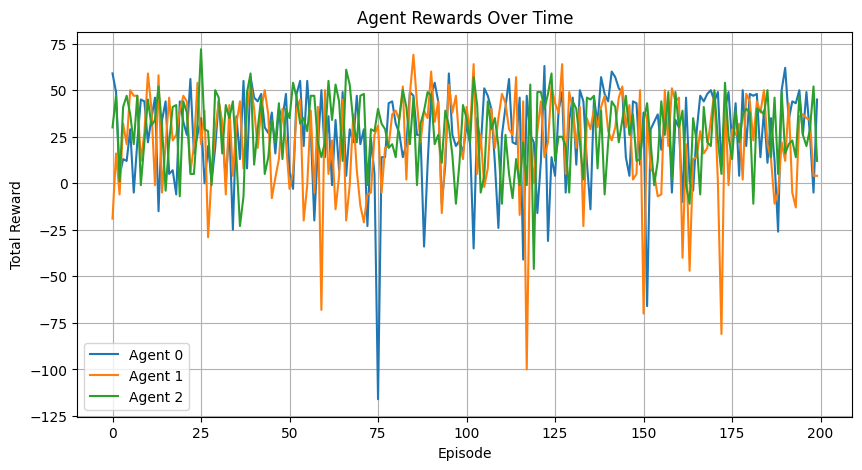

In [ ]:
def plot_rewards(reward_histories):
    plt.figure(figsize=(10, 5))
    for i, history in enumerate(reward_histories):
        plt.plot(history, label=f"Agent {i}")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("Agent Rewards Over Time")
    plt.legend()
    plt.grid()
    plt.show()

plot_rewards(reward_histories)


In [ ]:
for i, agent in enumerate(agents):
    torch.save(agent.model.state_dict(), f"agent_{i}_model.pth")


In [ ]:
import numpy as np

def smooth(data, weight=0.9):
    """ Exponential moving average smoothing """
    smoothed = []
    last = data[0]
    for point in data:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed


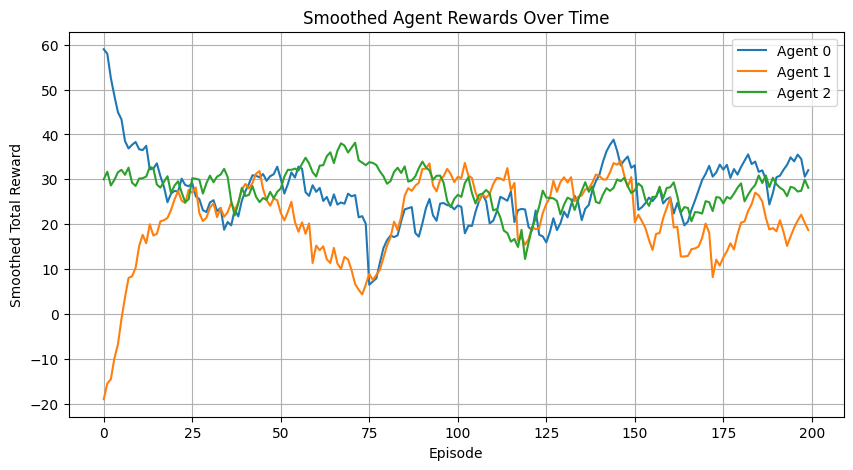

In [ ]:
def plot_smoothed_rewards(reward_histories):
    plt.figure(figsize=(10, 5))
    for i, history in enumerate(reward_histories):
        smoothed = smooth(history)
        plt.plot(smoothed, label=f"Agent {i}")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Total Reward")
    plt.title("Smoothed Agent Rewards Over Time")
    plt.legend()
    plt.grid()
    plt.show()

plot_smoothed_rewards(reward_histories)


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


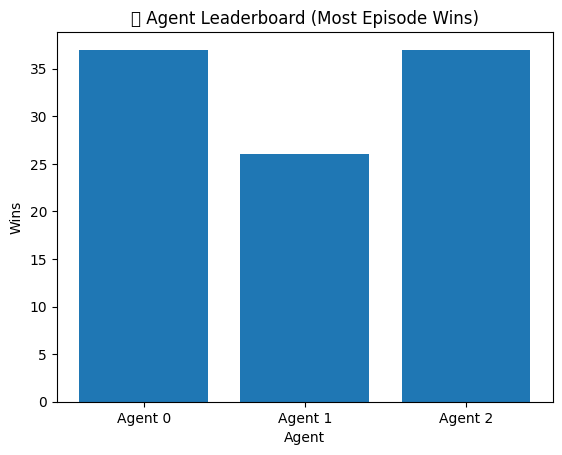

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

class DecentralizedAgent:
    def __init__(self, idx):
        self.idx = idx
        self.cwnd_history = []  # Track CWND history for visualization
        self.state = None  # Add agent state (e.g., CWND, RTT)
        self.action = None  # The action taken in the current step

    def reward(self):
        # Implement reward calculation logic here based on the agent's state.
        # For example, we will base it on the last value in CWND history or any other performance metric.
        if len(self.cwnd_history) > 0:
            return self.cwnd_history[-1]  # Example: CWND size as reward
        else:
            return 0  # Default reward when no history

    def take_action(self, action):
        # Add logic to take action, update state, and possibly record CWND values
        self.action = action
        # Example: Update state or CWND history
        self.cwnd_history.append(np.random.random())  # Simulate CWND changes for illustration

    def calculate_reward(self):
        # Optional: Separate reward calculation logic, if needed
        return self.reward()

# Number of episodes
num_episodes = 100  # Adjust as needed
leaderboard = []

# Initialize agents
agents = [DecentralizedAgent(idx) for idx in range(3)]  # Example with 3 agents

# Simulate for 'num_episodes'
for episode in range(num_episodes):
    total_rewards = []

    # Simulate or train agents for this episode
    for agent in agents:
        # Example action (you can modify this logic based on your RL agent behavior)
        action = np.random.choice([0, 1, 2])  # Random action placeholder
        agent.take_action(action)

        # Get reward based on current state
        agent_reward = agent.reward()
        total_rewards.append(agent_reward)

    # Track the best performer for this episode
    best_agent = np.argmax(total_rewards)
    leaderboard.append(best_agent)

# Plot the leaderboard (Most Episode Wins)
plt.hist(leaderboard, bins=[-0.5, 0.5, 1.5, 2.5], rwidth=0.8)
plt.xticks([0, 1, 2], ['Agent 0', 'Agent 1', 'Agent 2'])
plt.title("🏆 Agent Leaderboard (Most Episode Wins)")
plt.xlabel("Agent")
plt.ylabel("Wins")
plt.show()

# Save and Load agent models (if needed)
# Example for saving the model of the first agent
torch.save(agents[0].state, "agent_0_model.pt")

# Loading the model for the first agent
agents[0].state = torch.load("agent_0_model.pt")


In [ ]:
import torch

# Federated Averaging Function
def federated_averaging(agents):
    # Initialize a dictionary to hold the average model weights
    avg_weights = {}

    # Sum up the weights from all agents
    for agent in agents:
        agent_weights = agent.q_network.state_dict()  # Get the weights of the agent's model
        if not avg_weights:
            avg_weights = {k: v.clone() for k, v in agent_weights.items()}  # Initialize with the first agent's weights
        else:
            for k, v in avg_weights.items():
                avg_weights[k] += agent_weights[k]  # Accumulate weights

    # Average the weights
    num_agents = len(agents)
    for k, v in avg_weights.items():
        avg_weights[k] /= num_agents  # Average the accumulated weights

    # Update each agent's model with the new average weights
    for agent in agents:
        agent.q_network.load_state_dict(avg_weights)  # Load the averaged weights into each agent's model
        agent.q_network.eval()  # Set to evaluation mode (if needed)



Performing federated averaging at episode 10
Performing federated averaging at episode 20
Performing federated averaging at episode 30
Performing federated averaging at episode 40
Performing federated averaging at episode 50
Performing federated averaging at episode 60
Performing federated averaging at episode 70
Performing federated averaging at episode 80
Performing federated averaging at episode 90
Performing federated averaging at episode 100


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


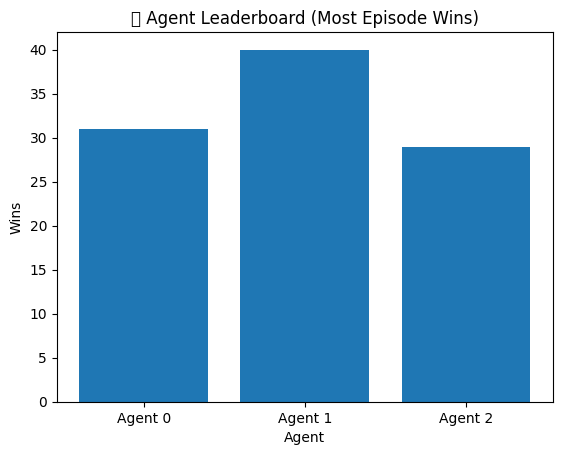

Sequential(
  (0): Linear(in_features=10, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=3, bias=True)
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Agent class remains the same as before
class DecentralizedAgent:
    def __init__(self, idx):
        self.idx = idx
        self.cwnd_history = []  # Track CWND history for visualization
        self.q_network = torch.nn.Sequential(  # Example simple neural network (you can adjust this)
            torch.nn.Linear(10, 10),  # Example input/output size
            torch.nn.ReLU(),
            torch.nn.Linear(10, 3)   # Output size for 3 actions
        )
        self.optimizer = torch.optim.Adam(self.q_network.parameters(), lr=0.001)

    def reward(self):
        if len(self.cwnd_history) > 0:
            return self.cwnd_history[-1]  # Reward based on last CWND value
        return 0

    def take_action(self, action):
        self.action = action
        self.cwnd_history.append(np.random.random())  # Simulated CWND change

# Number of episodes and federated update frequency
num_episodes = 100
federated_update_frequency = 10  # Update models every 10 episodes
leaderboard = []

# Initialize agents
agents = [DecentralizedAgent(idx) for idx in range(3)]

# Simulate for 'num_episodes'
for episode in range(num_episodes):
    total_rewards = []

    # Train agents for this episode
    for agent in agents:
        action = np.random.choice([0, 1, 2])  # Random action placeholder
        agent.take_action(action)
        agent_reward = agent.reward()  # Calculate the reward for this agent
        total_rewards.append(agent_reward)

    # Track the best performer for this episode
    best_agent = np.argmax(total_rewards)
    leaderboard.append(best_agent)

    # Apply Federated Averaging every 'federated_update_frequency' episodes
    if (episode + 1) % federated_update_frequency == 0:
        print(f"Performing federated averaging at episode {episode + 1}")
        federated_averaging(agents)  # Share and average model weights

# Plot the leaderboard (Most Episode Wins)
plt.hist(leaderboard, bins=[-0.5, 0.5, 1.5, 2.5], rwidth=0.8)
plt.xticks([0, 1, 2], ['Agent 0', 'Agent 1', 'Agent 2'])
plt.title("🏆 Agent Leaderboard (Most Episode Wins)")
plt.xlabel("Agent")
plt.ylabel("Wins")
plt.show()

# Save and Load agent models (if needed)
# Example for saving the model of the first agent
torch.save(agents[0].q_network.state_dict(), "agent_0_model.pt")

# Loading the model for the first agent
agents[0].q_network.load_state_dict(torch.load("agent_0_model.pt"))
agents[0].q_network.eval()


Performing federated averaging at episode 10
Performing federated averaging at episode 20
Performing federated averaging at episode 30
Performing federated averaging at episode 40
Performing federated averaging at episode 50
Performing federated averaging at episode 60
Performing federated averaging at episode 70
Performing federated averaging at episode 80
Performing federated averaging at episode 90
Performing federated averaging at episode 100


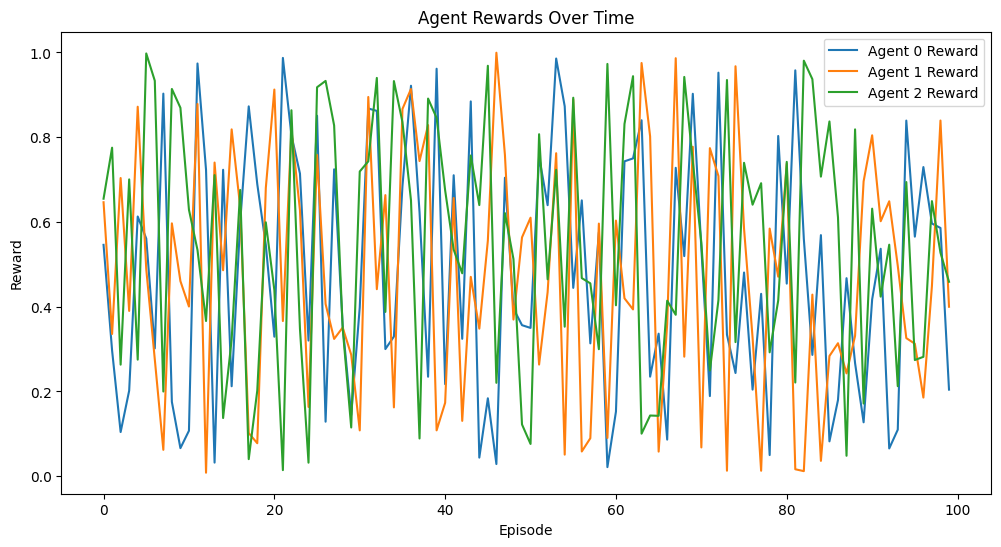

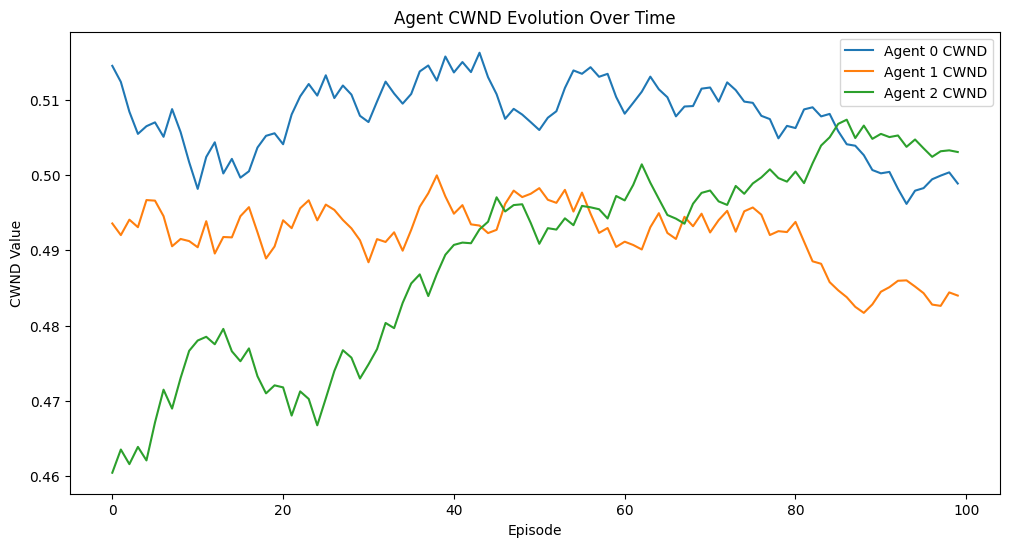

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Track rewards and CWND for each agent
rewards_history = {i: [] for i in range(3)}  # To track reward history for each agent
cwnd_history = {i: [] for i in range(3)}  # To track CWND history for each agent

# Modify the training loop to record the rewards and CWND
for episode in range(num_episodes):
    total_rewards = []

    # Train agents for this episode
    for agent in agents:
        action = np.random.choice([0, 1, 2])  # Random action placeholder
        agent.take_action(action)
        agent_reward = agent.reward()  # Calculate the reward for this agent
        total_rewards.append(agent_reward)

        # Track rewards and CWND history
        rewards_history[agent.idx].append(agent_reward)
        cwnd_history[agent.idx].append(np.mean(agent.cwnd_history))  # Mean CWND value for this agent

    # Track the best performer for this episode
    best_agent = np.argmax(total_rewards)
    leaderboard.append(best_agent)

    # Apply Federated Averaging every 'federated_update_frequency' episodes
    if (episode + 1) % federated_update_frequency == 0:
        print(f"Performing federated averaging at episode {episode + 1}")
        federated_averaging(agents)  # Share and average model weights

# Plot the reward history over episodes
plt.figure(figsize=(12, 6))
for agent_idx in range(3):
    plt.plot(range(num_episodes), rewards_history[agent_idx], label=f'Agent {agent_idx} Reward')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Agent Rewards Over Time')
plt.legend()
plt.show()

# Plot CWND history for each agent
plt.figure(figsize=(12, 6))
for agent_idx in range(3):
    plt.plot(range(num_episodes), cwnd_history[agent_idx], label=f'Agent {agent_idx} CWND')
plt.xlabel('Episode')
plt.ylabel('CWND Value')
plt.title('Agent CWND Evolution Over Time')
plt.legend()
plt.show()


In [ ]:
# Parameters for epsilon decay
epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995  # Decay rate for epsilon

# Modify the epsilon update inside your main training loop
epsilon = epsilon_start
for episode in range(num_episodes):
    total_rewards = []

    # Train agents for this episode
    for agent in agents:
        action = np.random.choice([0, 1, 2])  # Random action placeholder (change with epsilon-greedy)
        agent.take_action(action)
        agent_reward = agent.reward()
        total_rewards.append(agent_reward)

        # Update epsilon (exploration vs exploitation balance)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # Track the best performer for this episode
    best_agent = np.argmax(total_rewards)
    leaderboard.append(best_agent)

    # Apply Federated Averaging every 'federated_update_frequency' episodes
    if (episode + 1) % federated_update_frequency == 0:
        print(f"Performing federated averaging at episode {episode + 1}")
        federated_averaging(agents)

# Check the final epsilon value
print(f"Final epsilon: {epsilon}")


Performing federated averaging at episode 10
Performing federated averaging at episode 20
Performing federated averaging at episode 30
Performing federated averaging at episode 40
Performing federated averaging at episode 50
Performing federated averaging at episode 60
Performing federated averaging at episode 70
Performing federated averaging at episode 80
Performing federated averaging at episode 90
Performing federated averaging at episode 100
Final epsilon: 0.22229219984074702


In [ ]:
# Parameters for learning rate decay
lr_start = 0.001
lr_min = 0.0001
lr_decay = 0.995  # Decay rate for learning rate

# Modify the optimizer initialization and decay
for episode in range(num_episodes):
    total_rewards = []

    # Train agents for this episode
    for agent in agents:
        action = np.random.choice([0, 1, 2])  # Random action placeholder
        agent.take_action(action)
        agent_reward = agent.reward()
        total_rewards.append(agent_reward)

        # Update learning rate (with decay)
        for param_group in agent.optimizer.param_groups:
            param_group['lr'] = max(lr_min, param_group['lr'] * lr_decay)

    # Track the best performer for this episode
    best_agent = np.argmax(total_rewards)
    leaderboard.append(best_agent)

    # Apply Federated Averaging every 'federated_update_frequency' episodes
    if (episode + 1) % federated_update_frequency == 0:
        print(f"Performing federated averaging at episode {episode + 1}")
        federated_averaging(agents)

# Check the final learning rate
print(f"Final learning rate: {agent.optimizer.param_groups[0]['lr']}")


Performing federated averaging at episode 10
Performing federated averaging at episode 20
Performing federated averaging at episode 30
Performing federated averaging at episode 40
Performing federated averaging at episode 50
Performing federated averaging at episode 60
Performing federated averaging at episode 70
Performing federated averaging at episode 80
Performing federated averaging at episode 90
Performing federated averaging at episode 100
Final learning rate: 0.0006057704364907278
